# Complete Machine Learning Pipeline Guide: Chapters 6–15

> **Purpose:** This notebook walks you through the full ML workflow — from raw data to tuned, evaluated models — following the sequence taught in Chapters 6 through 15. Every section contains clear instructions; you write the code in the placeholder cells below each instruction block.
>
> **General-purpose design:** No dataset is hardcoded. Wherever a column name or file path appears, replace it with your own.
>
> **How to use this notebook:**
> 1. Work top-to-bottom through Sections 1–5 for every project.
> 2. At **Section 6**, choose your modeling goal (causal vs. predictive, numeric vs. categorical label) and follow the corresponding path(s).
> 3. End with **Section 9 (Ch. 15)** to rigorously evaluate and tune your final model.

---

| Section | Chapter | Topic |
|---------|---------|-------|
| 1 | — | Setup & Imports |
| 2 | Ch. 6 | Load & Inspect Data |
| 3 | Ch. 6 | Univariate EDA |
| 4 | Ch. 7 | Data Cleaning |
| 5 | Ch. 8 | Bivariate Analysis |
| 6 | — | Define Modeling Goal |
| 7A | Ch. 9–10 | **Causal Model — Numeric Label** (MLR + Diagnostics) |
| 7B | — | **Causal Model — Categorical Label** (Logistic Regression) |
| 8A | Ch. 11–12 | **Predictive Model — Numeric Label** (Linear Reg + Decision Tree) |
| 8B | Ch. 13–14 | **Predictive Model — Categorical Label** (DT Classifier + Ensembles) |
| 9 | Ch. 15 | Model Evaluation, Selection & Tuning |


---
## Section 1 — Setup & Imports
*(All Chapters)*

Import every library used throughout this pipeline. Run this cell first, every time you open the notebook. Add any additional packages you need as you work through the sections.

In [73]:
# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Scikit-Learn: Preprocessing & Pipelines ──────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_validate, StratifiedKFold,
    learning_curve, validation_curve, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Scikit-Learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# ── Scikit-Learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, log_loss, roc_auc_score
)

# ── Statsmodels (causal/explanatory modeling) ─────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import omni_normtest

# ── Optional: XGBoost (install with: pip install xgboost) ────────────────────
# from xgboost import XGBClassifier

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)


---
## Section 2 — Load & Inspect the Dataset
*(Chapter 6)*

### 2.1 Load the Data

Load your dataset from a CSV (or other file format) into a Pandas DataFrame. Replace `'your_file.csv'` with your actual file path.

In [74]:
# Load ALL tables from the course shop.db into one combined DataFrame called `df`
import sqlite3
from pathlib import Path

# Use the DB that's one folder up from this notebook (avoids creating an empty ./shop.db)
DB_PATH = Path.cwd().parent / 'database' / 'shop.db'

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Couldn't find the database at {str(DB_PATH)!r}. "
        "If your DB is elsewhere, update DB_PATH to that full path."
    )

with sqlite3.connect(str(DB_PATH)) as conn:
    table_names = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'",
        conn,
    )["name"].tolist()

    if not table_names:
        raise ValueError(f"No tables found in {str(DB_PATH)!r}")

    dfs = []
    for name in table_names:
        tdf = pd.read_sql_query(f'SELECT * FROM "{name}"', conn)
        tdf["__table"] = name
        dfs.append(tdf)

df = pd.concat(dfs, ignore_index=True, sort=False)

# Keep the rest of the notebook working
df_raw = df


### 2.2 Initial Inspection

Print the shape (rows × columns) and the first several rows. This confirms the file loaded correctly and gives you a first look at the data's structure.

In [75]:
print("Shape:", df.shape)
df.head()


Shape: (33372, 57)


,customer_id,full_name,email,gender,birthdate,created_at,city,state,zip_code,customer_segment,loyalty_tier,is_active,__table,product_id,sku,product_name,category,price,cost,order_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,order_item_id,quantity,unit_price,line_total,shipment_id,ship_datetime,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery,review_id,rating,review_datetime,review_text,prediction_id,predicted_priority_score,priority_bucket,estimated_ship_hours,prediction_reason,scored_at
0,1.0000,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0000,Juan Flores,juanflores1@example.com,Male,1995-05-29,2025-10-11 16:37:40,Hudson,CO,88907,budget,none,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0000,Mary González,marygonzález2@example.com,Female,2005-06-30,2025-06-26 16:37:40,Oxford,OH,46421,budget,gold,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0000,Omar Fischer,omarfischer3@example.com,Male,2005-08-13,2025-07-17 16:37:40,Riverton,NC,70217,standard,gold,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0000,Salma Sullivan,salmasullivan4@example.com,Female,1971-11-29,2025-02-14 16:37:40,Franklin,AZ,16006,standard,silver,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.3 Data Types Overview

Print the data types of all columns. This helps you identify which columns are numeric, which are categorical (object), and which may need type corrections (e.g., a numeric-looking column stored as a string).

In [76]:
print(df.dtypes)


customer_id                 float64
full_name                       str
email                           str
gender                          str
birthdate                       str
created_at                      str
city                            str
state                           str
zip_code                        str
customer_segment                str
loyalty_tier                    str
is_active                   float64
__table                         str
product_id                  float64
sku                             str
product_name                    str
category                        str
price                       float64
cost                        float64
order_id                    float64
order_datetime                  str
billing_zip                     str
shipping_zip                    str
shipping_state                  str
payment_method                  str
device_type                     str
ip_country                      str
promo_used                  

---
## Section 3 — Univariate EDA
*(Chapter 6)*

Univariate analysis examines each column individually — one variable at a time — before looking at relationships between variables.

### 3.1 Build the `univariate()` Function

Build a function called `univariate(df, show_stats=True, show_plots=True)` that:

- Iterates over every column in the DataFrame
- Computes a **statistics table** containing:
  - `Count`, `Missing`, `Missing%`, `Unique`, `Type`
  - For **numeric columns**: `Min`, `Max`, `25%`, `50%`, `75%`, `Mean`, `Median`, `Mode`, `Std`, `Skew`, `Kurt`
  - For **categorical columns**: fill numeric stat columns with `'-'`
- Contains a nested `histogram(series, show_stats)` function that plots a histogram with optional overlay of `Min`, `Max`, `Mean`, `Std`, and `Skew`
- Contains a nested `countplot(series, show_stats)` function that plots a bar chart with optional overlay of total count and missing value count
- Calls `histogram()` for numeric columns and `countplot()` for categorical columns when `show_plots=True`
- Returns the statistics table DataFrame

**Parameters:**
- `df` — any Pandas DataFrame
- `show_stats` — boolean; if `True`, print the statistics table
- `show_plots` — boolean; if `True`, display a chart for each column

In [77]:
def histogram(series, show_stats=True):
    s = series.dropna()

    plt.figure(figsize=(8, 3))
    sns.histplot(s, bins=30, kde=True)
    plt.title(series.name)

    if show_stats and len(s) > 0:
        mn = float(s.min())
        mx = float(s.max())
        mean = float(s.mean())
        std = float(s.std(ddof=1)) if len(s) > 1 else 0.0
        skew = float(s.skew()) if len(s) > 2 else 0.0

        plt.axvline(mn, color="gray", linestyle="--", linewidth=1, label=f"min={mn:.3g}")
        plt.axvline(mx, color="gray", linestyle=":", linewidth=1, label=f"max={mx:.3g}")
        plt.axvline(mean, color="C1", linestyle="-", linewidth=1, label=f"mean={mean:.3g}")
        plt.axvline(mean - std, color="C1", linestyle="--", linewidth=1, label=f"±1 std={std:.3g}")
        plt.axvline(mean + std, color="C1", linestyle="--", linewidth=1)
        plt.legend(loc="best")
        plt.text(
            0.99,
            0.95,
            f"skew={skew:.3g}",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
        )

    plt.tight_layout()
    plt.show()


def countplot(series, show_stats=True):
    plt.figure(figsize=(8, 3))
    s = series.astype("object")

    vc = s.value_counts(dropna=False)
    if len(vc) > 30:
        vc = vc.iloc[:30]

    sns.barplot(x=vc.index.astype(str), y=vc.values)
    plt.title(series.name)
    plt.xticks(rotation=45, ha="right")

    if show_stats:
        total = int(len(s))
        missing = int(s.isna().sum())
        plt.text(
            0.99,
            0.95,
            f"count={total}  missing={missing}",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
        )

    plt.tight_layout()
    plt.show()


def univariate(df, show_stats=True, show_plots=True):
    numeric_stats_cols = [
        "Min",
        "Max",
        "25%",
        "50%",
        "75%",
        "Mean",
        "Median",
        "Mode",
        "Std",
        "Skew",
        "Kurt",
    ]

    rows = []
    for col in df.columns:
        s = df[col]
        total = int(len(s))
        missing = int(s.isna().sum())
        count = int(s.notna().sum())
        missing_pct = (missing / total * 100) if total else 0.0
        unique = int(s.nunique(dropna=True))

        is_num = pd.api.types.is_numeric_dtype(s)
        row = {
            "Column": col,
            "Count": count,
            "Missing": missing,
            "Missing%": round(missing_pct, 2),
            "Unique": unique,
            "Type": str(s.dtype),
        }

        if is_num:
            sn = pd.to_numeric(s, errors="coerce").dropna()
            if len(sn) > 0:
                desc = sn.describe(percentiles=[0.25, 0.5, 0.75])
                mode_val = sn.mode(dropna=True)
                row.update(
                    {
                        "Min": float(desc["min"]),
                        "Max": float(desc["max"]),
                        "25%": float(desc["25%"]),
                        "50%": float(desc["50%"]),
                        "75%": float(desc["75%"]),
                        "Mean": float(desc["mean"]),
                        "Median": float(sn.median()),
                        "Mode": float(mode_val.iloc[0]) if len(mode_val) else np.nan,
                        "Std": float(sn.std(ddof=1)) if len(sn) > 1 else 0.0,
                        "Skew": float(sn.skew()) if len(sn) > 2 else 0.0,
                        "Kurt": float(sn.kurt()) if len(sn) > 3 else 0.0,
                    }
                )
            else:
                row.update({k: np.nan for k in numeric_stats_cols})
        else:
            row.update({k: "-" for k in numeric_stats_cols})

        rows.append(row)

        if show_plots:
            if is_num:
                histogram(s, show_stats=show_stats)
            else:
                countplot(s, show_stats=show_stats)

    stats_table = pd.DataFrame(rows).set_index("Column")

    if show_stats:
        display(stats_table)

    return stats_table


### 3.2 Run Univariate Analysis on the Full Dataset

Call `univariate()` on your DataFrame to review every column's statistics and distribution. Use the output to:
- Spot columns with high missing rates
- Identify numeric columns with significant skew (|skew| > 1 suggests transformation may help)
- Note categorical columns with many unique values (may need binning later)
- Detect potential data quality issues (e.g., unexpected unique values in what should be a boolean)

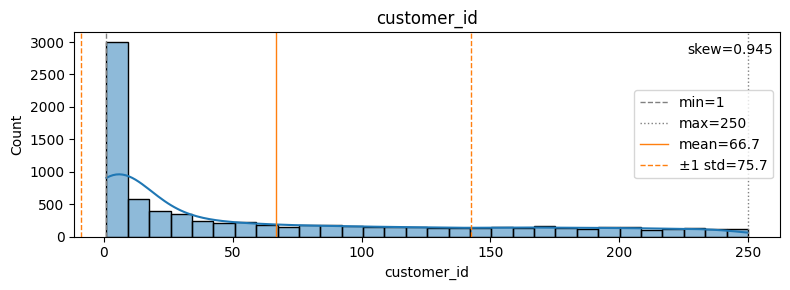

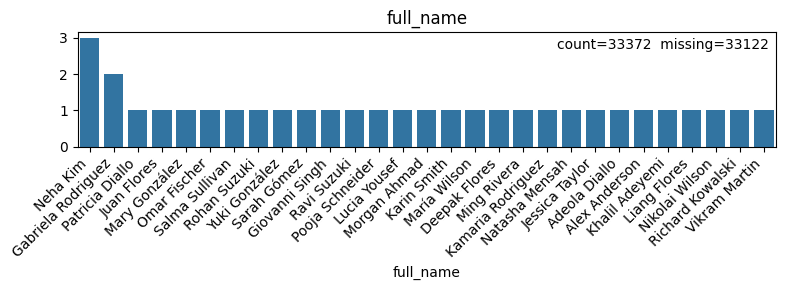

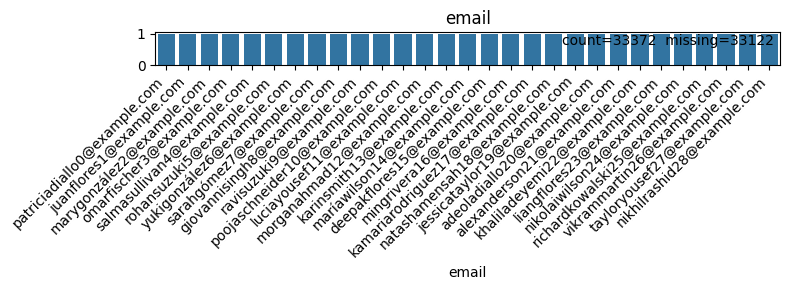

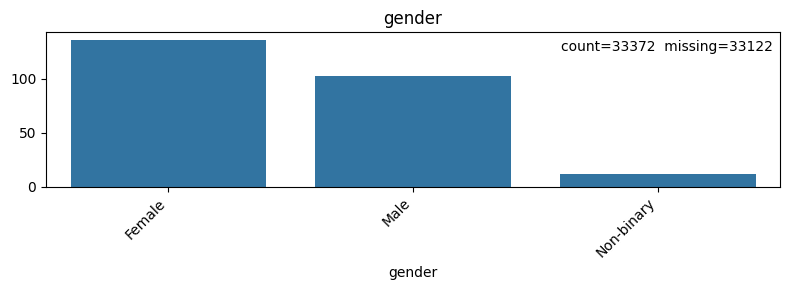

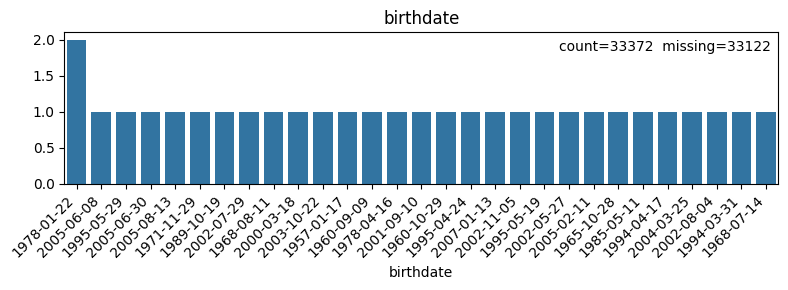

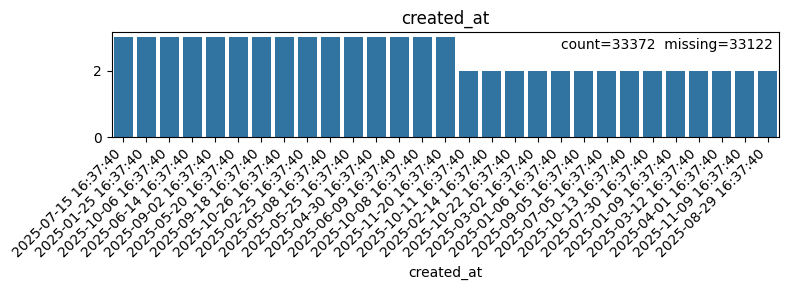

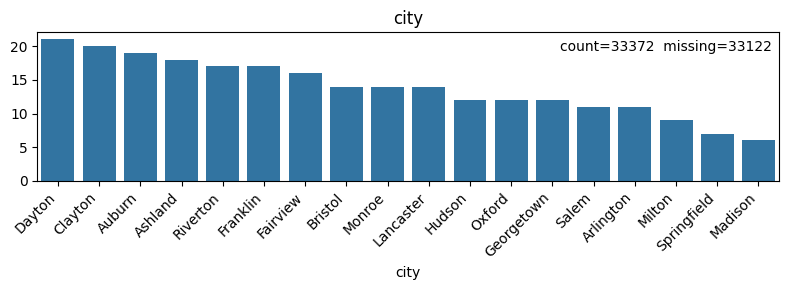

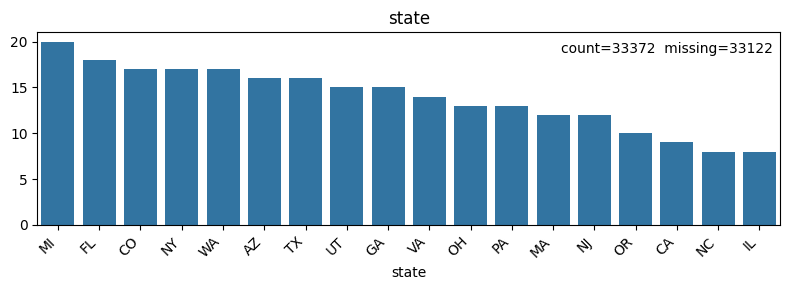

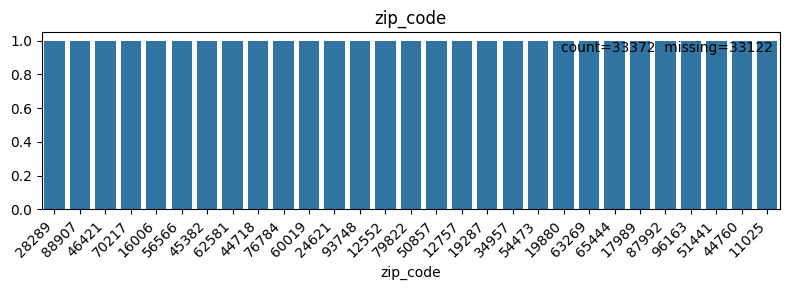

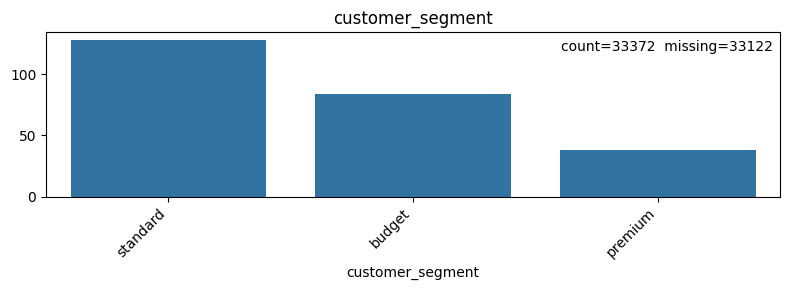

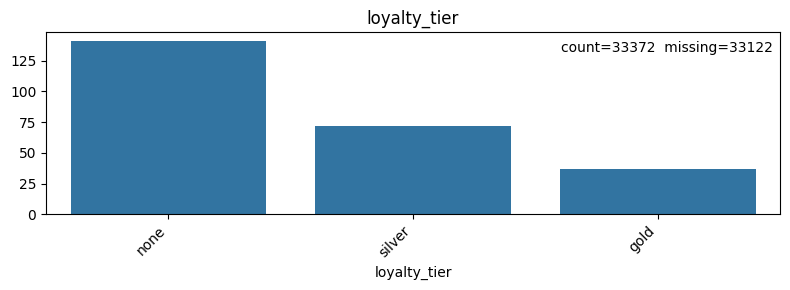

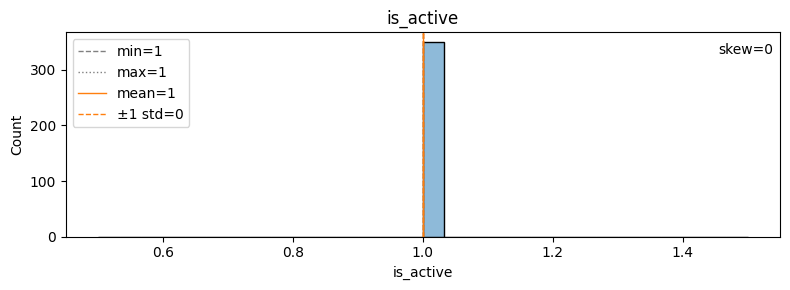

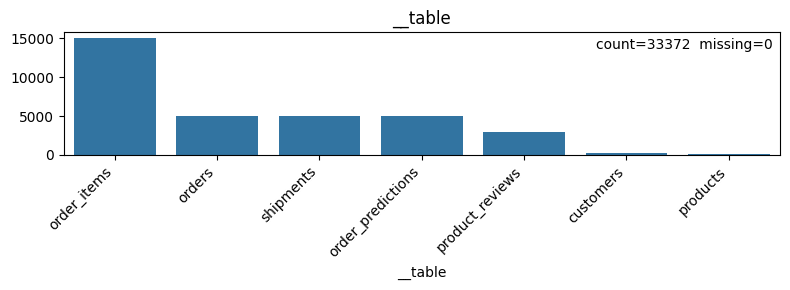

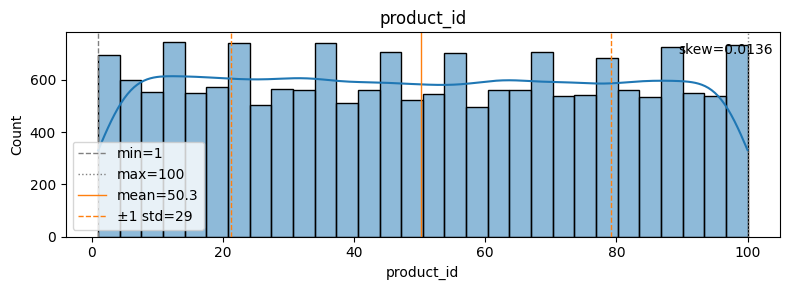

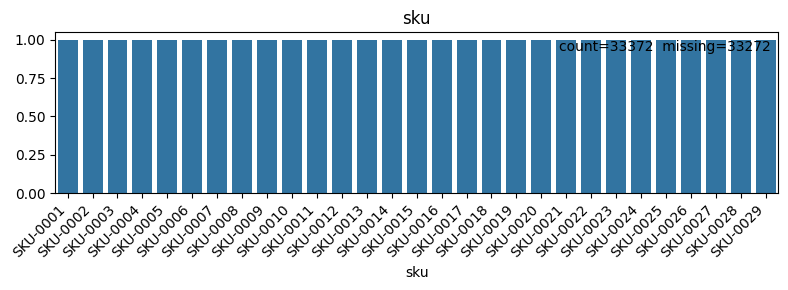

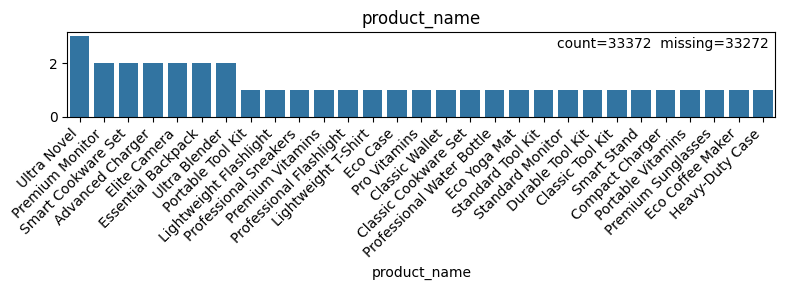

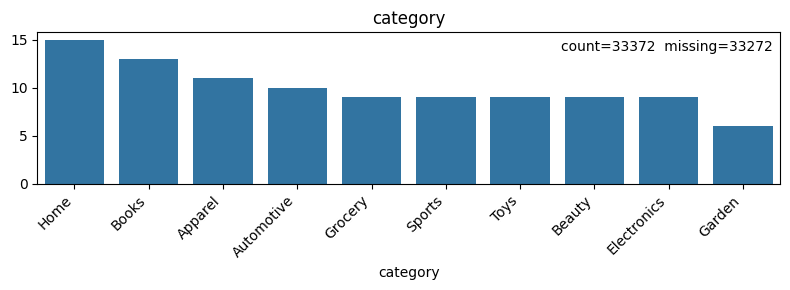

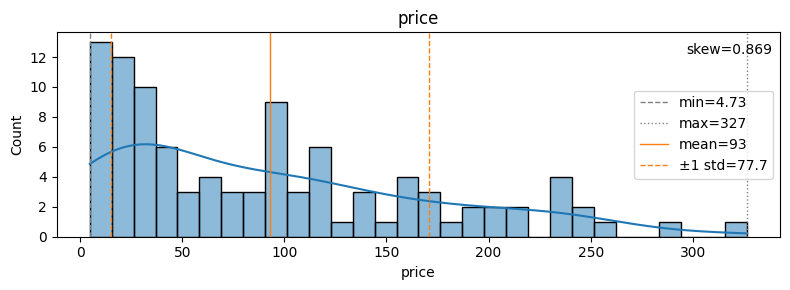

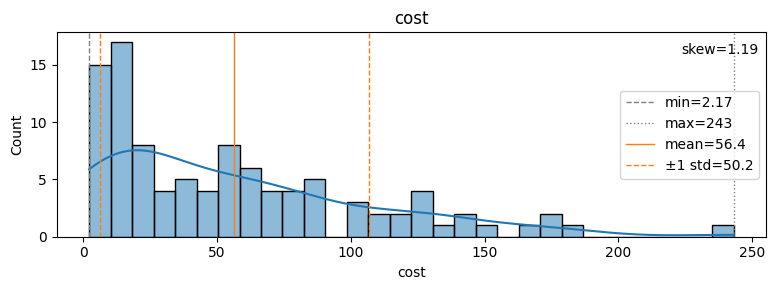

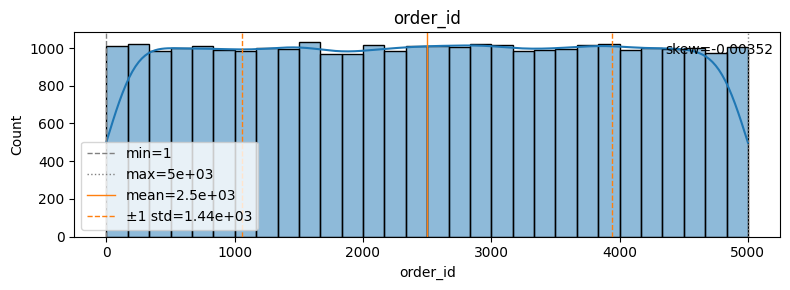

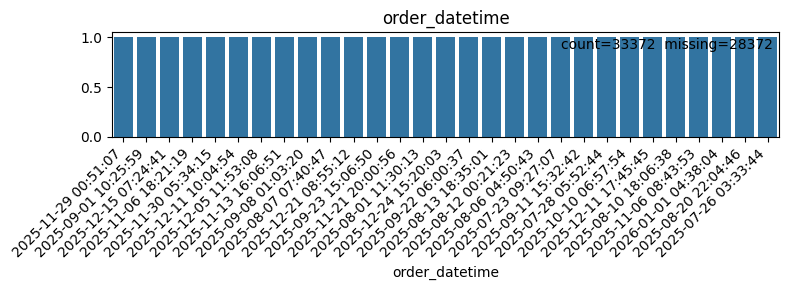

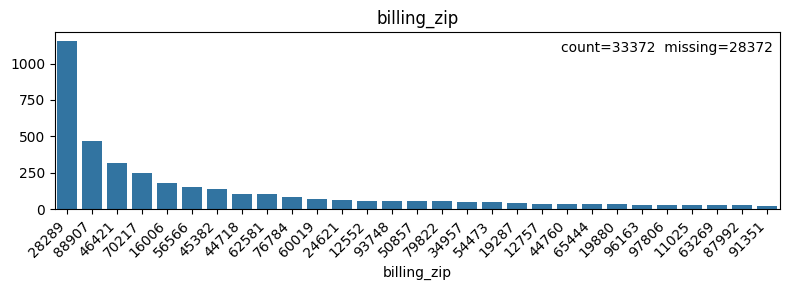

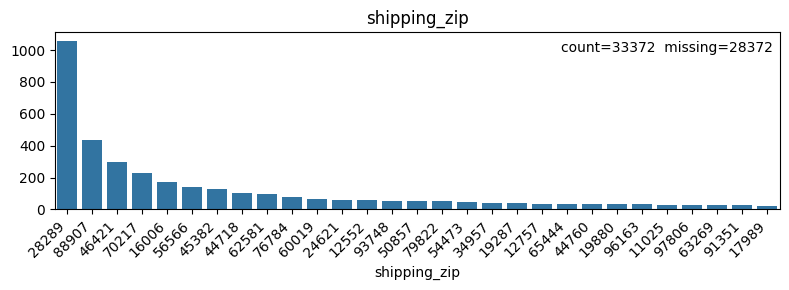

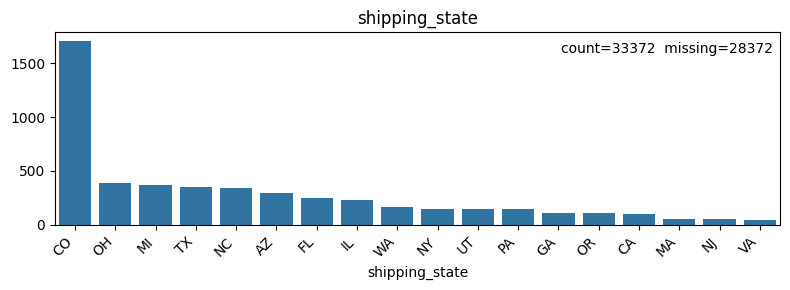

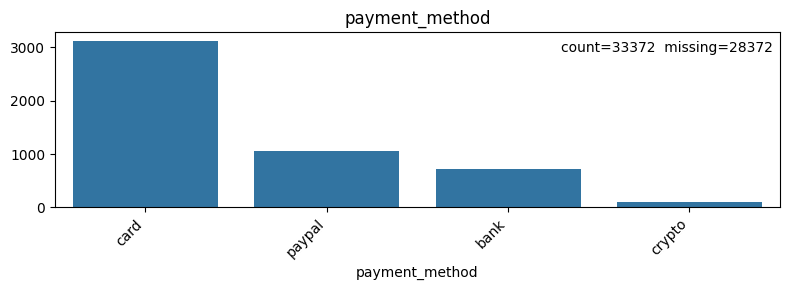

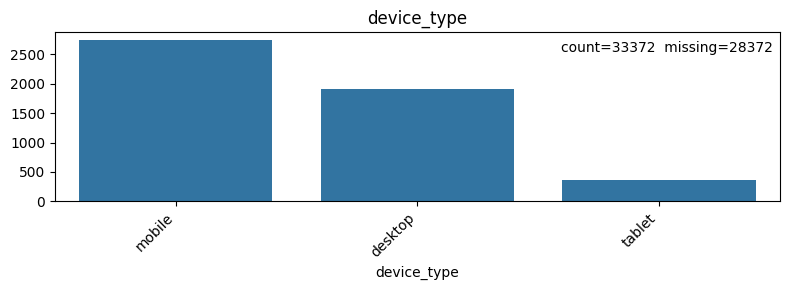

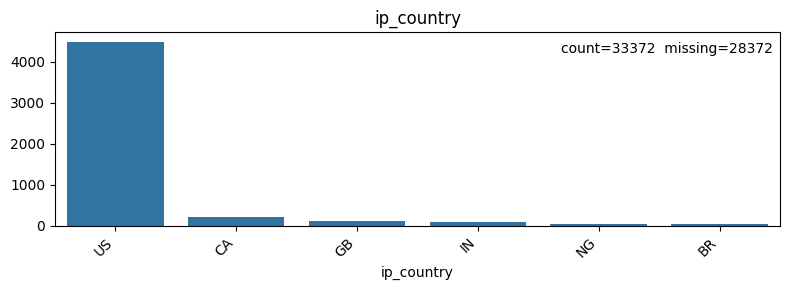

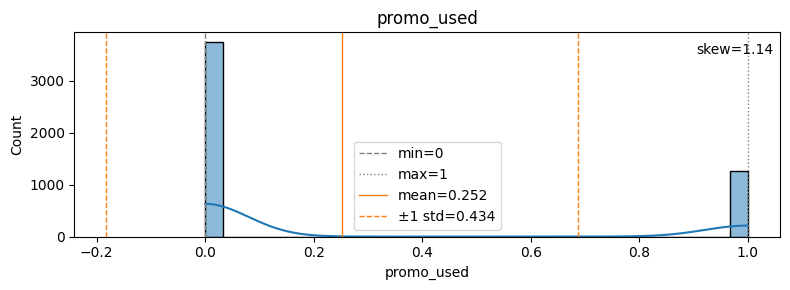

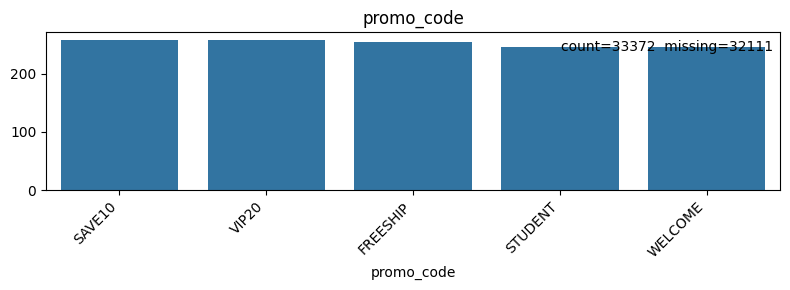

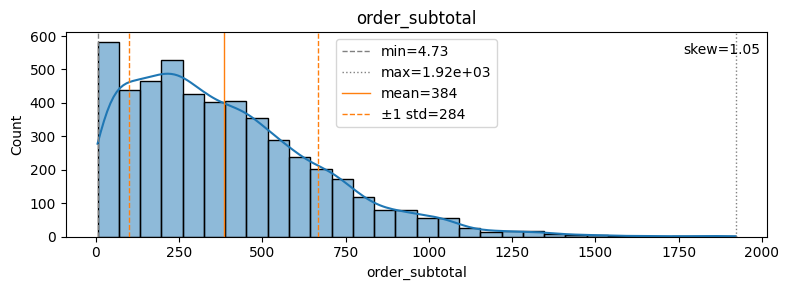

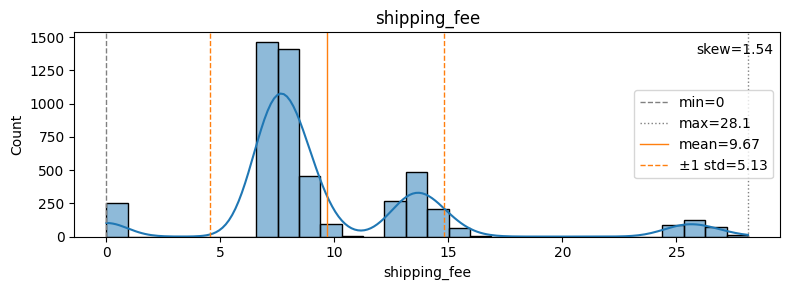

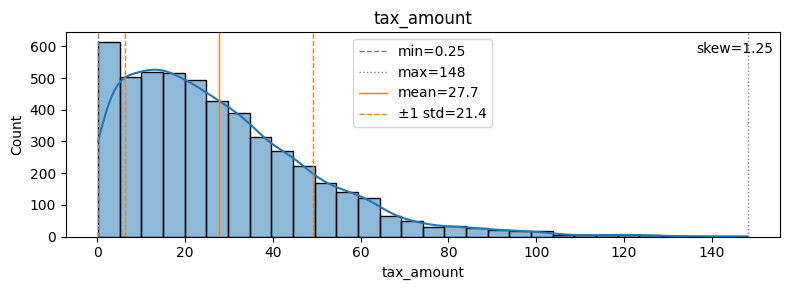

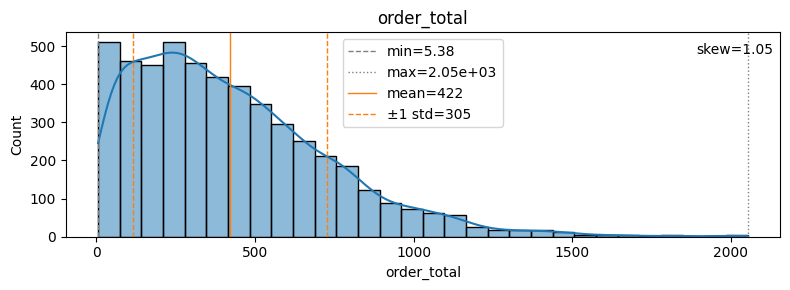

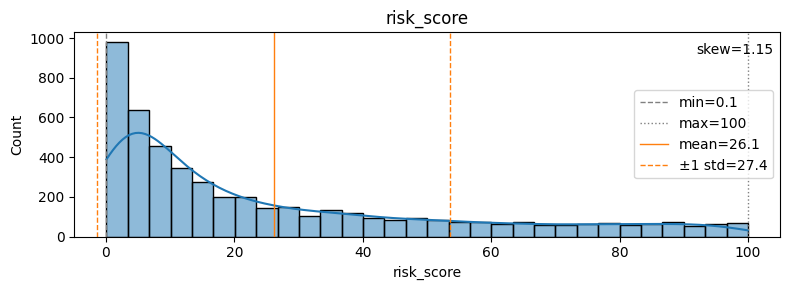

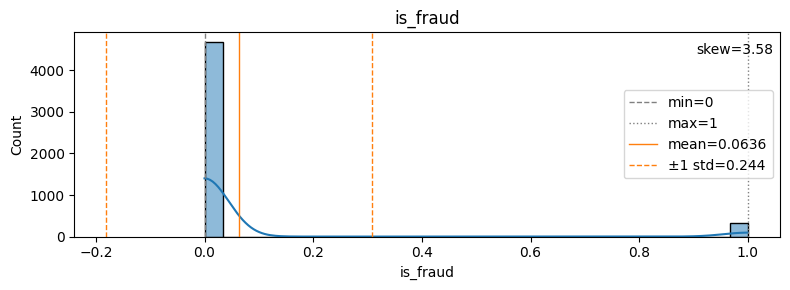

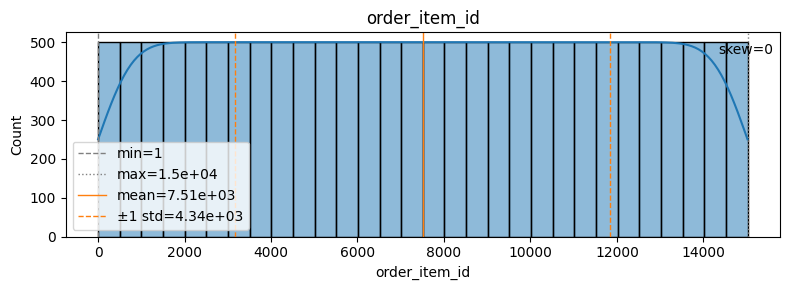

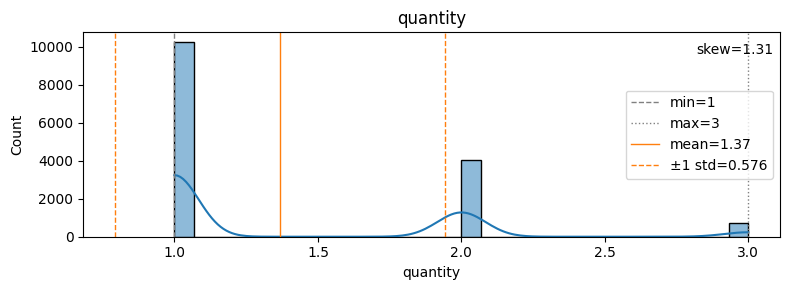

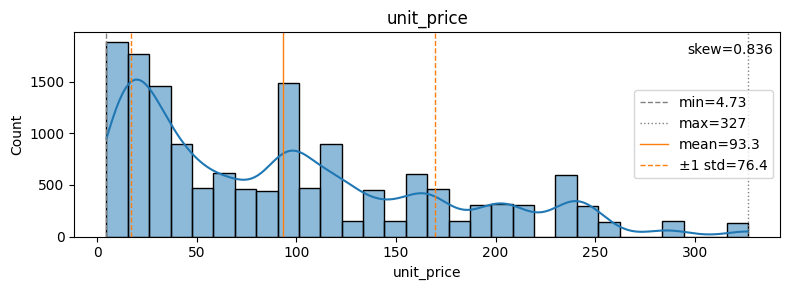

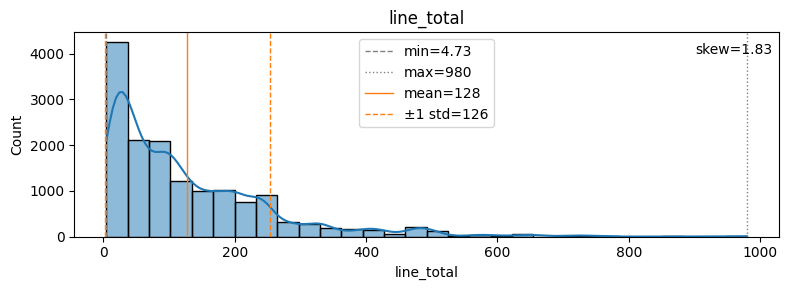

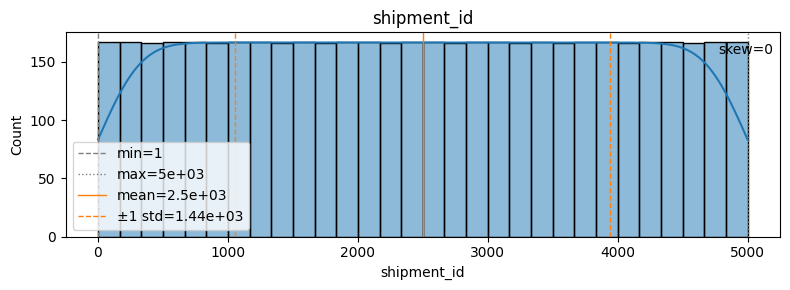

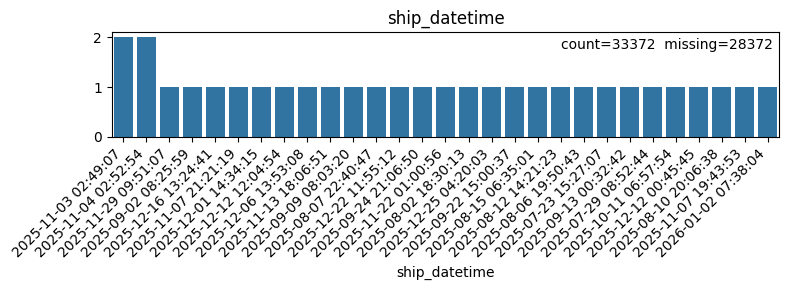

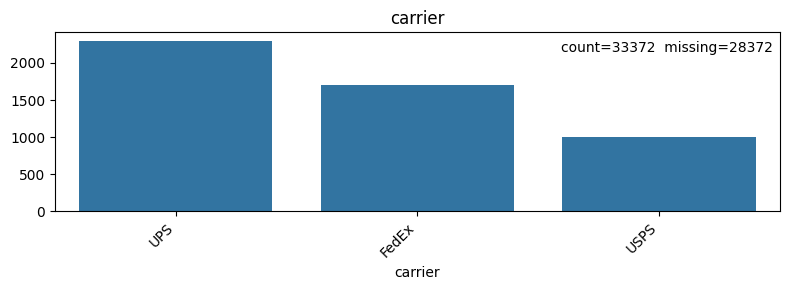

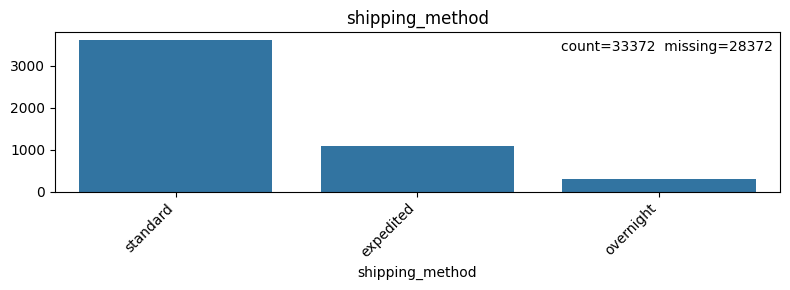

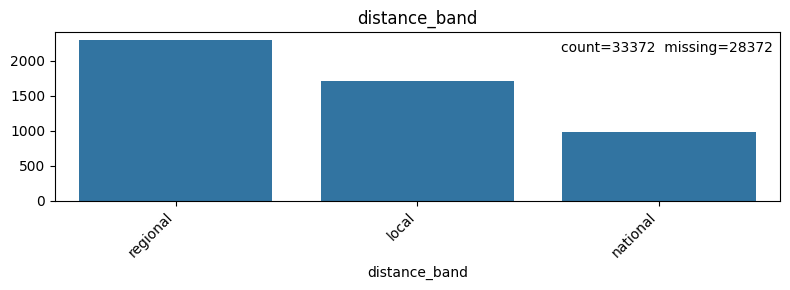

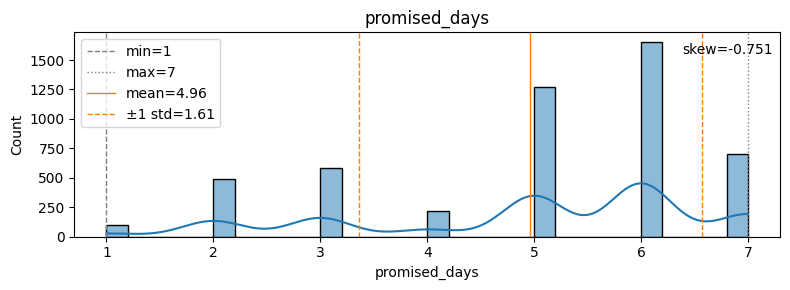

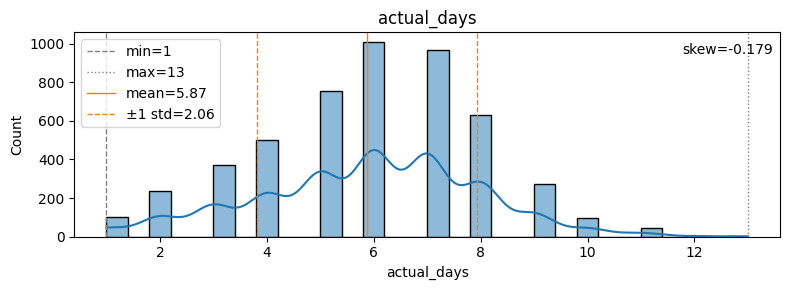

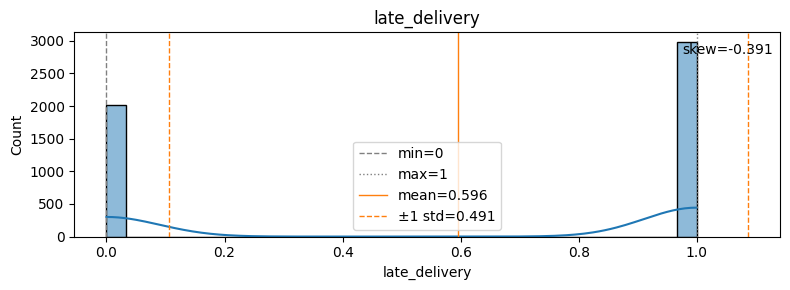

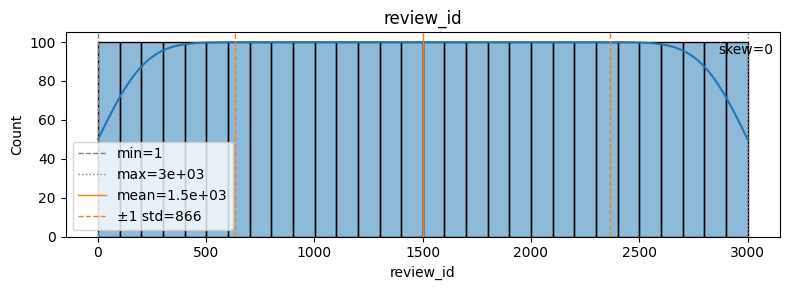

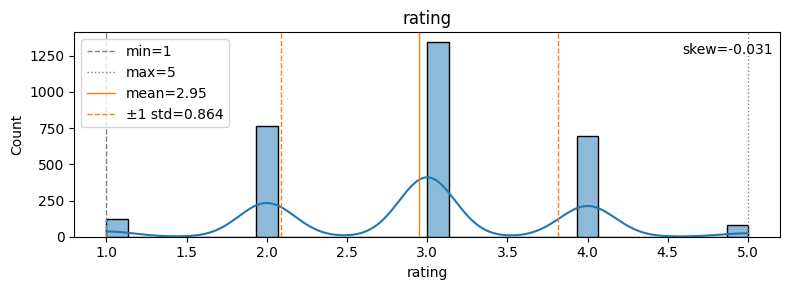

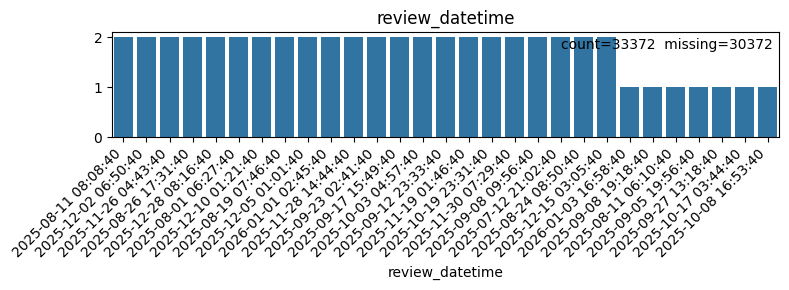

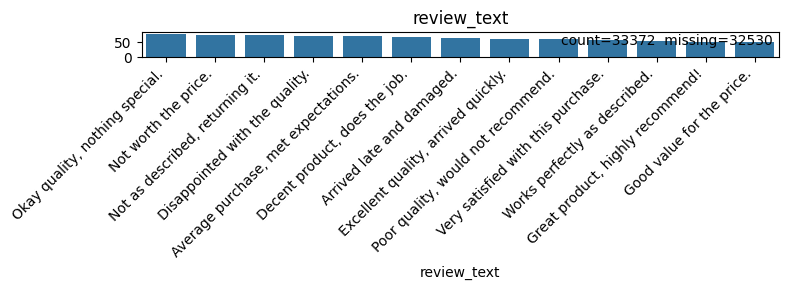

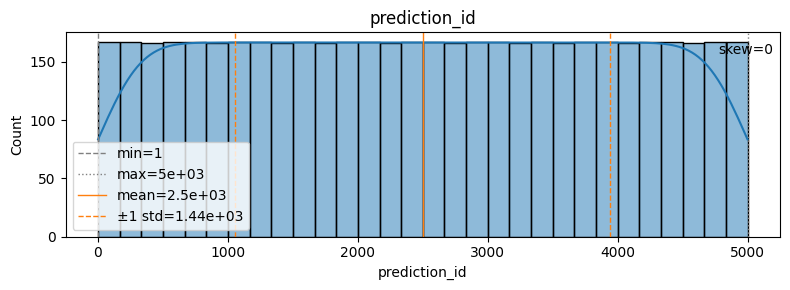

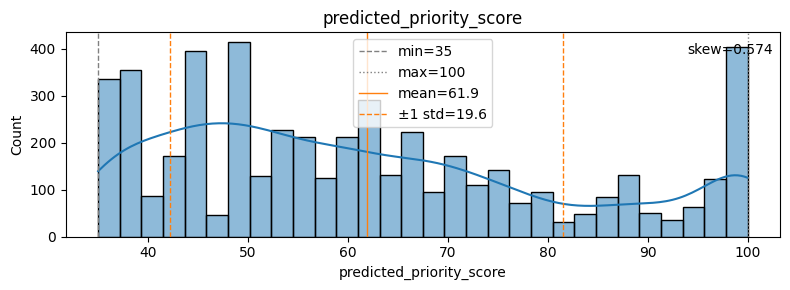

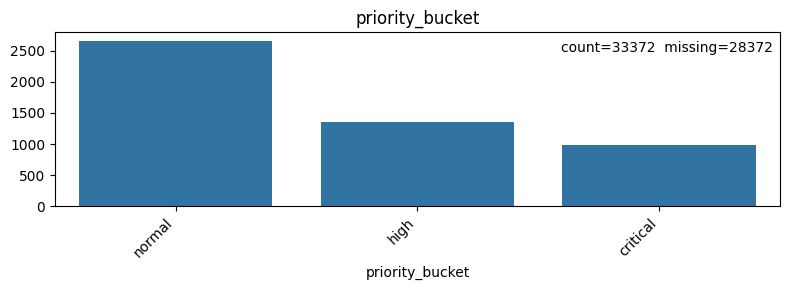

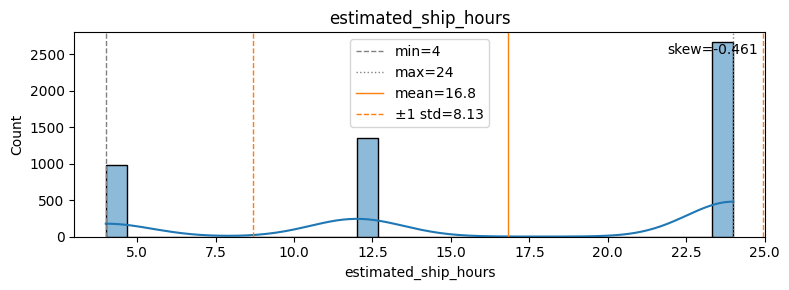

C:\Users\camjw\AppData\Local\Temp\ipykernel_18292\1406636372.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


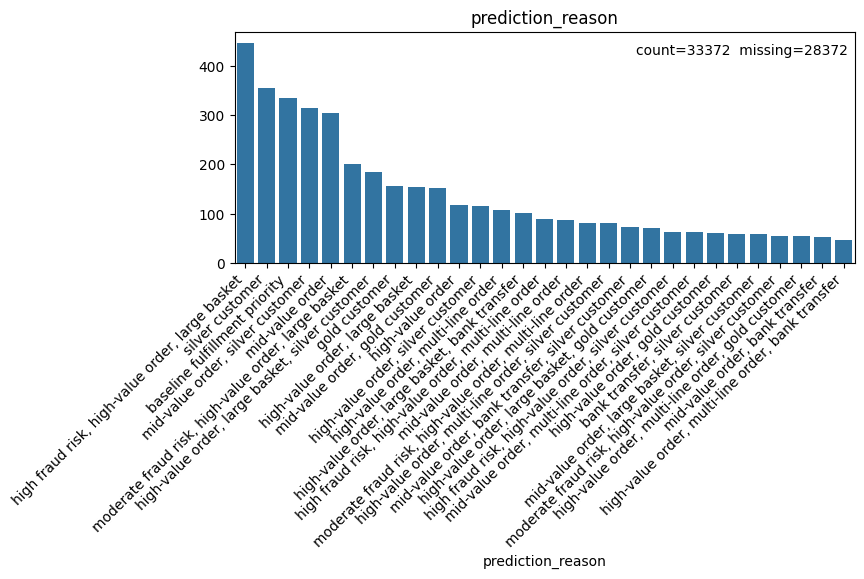

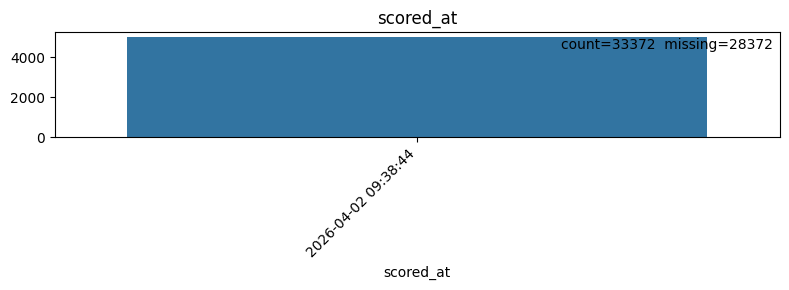

,Count,Missing,Missing%,Unique,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
Column,,,,,,,,,,,,,,,,
customer_id,8250,25122,75.2800,250,float64,1.0000,250.0000,4.0000,29.0000,120.0000,66.7218,29.0000,1.0000,75.7086,0.9449,-0.4796
full_name,250,33122,99.2500,247,str,-,-,-,-,-,-,-,-,-,-,-
email,250,33122,99.2500,250,str,-,-,-,-,-,-,-,-,-,-,-
gender,250,33122,99.2500,3,str,-,-,-,-,-,-,-,-,-,-,-
birthdate,250,33122,99.2500,249,str,-,-,-,-,-,-,-,-,-,-,-
created_at,250,33122,99.2500,177,str,-,-,-,-,-,-,-,-,-,-,-
city,250,33122,99.2500,18,str,-,-,-,-,-,-,-,-,-,-,-
state,250,33122,99.2500,18,str,-,-,-,-,-,-,-,-,-,-,-
zip_code,250,33122,99.2500,250,str,-,-,-,-,-,-,-,-,-,-,-


In [78]:
stats_table = univariate(df, show_stats=True, show_plots=True)


---
## Section 4 — Data Cleaning
*(Chapter 7)*

Work through the cleaning sub-steps below **in order**. Each function is designed to be reusable and non-destructive (creating new columns rather than overwriting originals). Chain the output of each step into the next.

> **Note:** Not every sub-step will apply to every dataset. Read the instructions for each step and skip it if it is not relevant to your data.

### 4.1 Clean Categorical Text Fields — `wrangle_basic(df)`

Many real-world datasets have categorical columns with inconsistent text entry: mixed casing, extra whitespace, abbreviations, typos, etc. Build a function `wrangle_basic(df)` that:

- Identifies which categorical (object) columns have data quality issues by inspecting `.unique()` values
- Creates cleaned copies of those columns (append `_clean` to the name; **do not** overwrite originals)
- Standardizes values so semantically identical entries are represented consistently (e.g., `'Yes'`, `'yes'`, `'YES'` → `'yes'`)
- Common operations to apply:
  - `.str.strip()` — remove leading/trailing whitespace
  - `.str.lower()` (or `.str.title()`) — normalize casing
  - `.str.replace()` — fix known abbreviation/typo variants
- Preserves all rows
- Returns the cleaned DataFrame

After running the function, inspect `.value_counts()` on cleaned columns to verify the results.

In [79]:
def wrangle_basic(df, label_col=None):
    """Basic string cleanup for categorical/text fields.

    Creates `*_clean` versions, but skips obvious artifacts (like `__*`) and the label.
    """
    obj_cols = df.select_dtypes(include=["object", "string"]).columns

    for col in obj_cols:
        if label_col and col == label_col:
            continue
        if col.startswith("__"):
            continue

        cleaned = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({"": pd.NA, "nan": pd.NA, "none": pd.NA, "null": pd.NA})
        )

        # Common small normalizations (extend if you find more variants)
        cleaned = cleaned.replace({"y": "yes", "n": "no", "t": "true", "f": "false"})

        df[f"{col}_clean"] = cleaned

    return df

# Apply cleaning (keep originals; add *_clean columns)
LABEL_COL = globals().get("CAT_LABEL", globals().get("LABEL", "is_fraud"))
df = wrangle_basic(df.copy(), label_col=LABEL_COL)


### 4.2 Handle Datetime Features — `add_datetime_features(df)`

Date and time columns stored as strings must be converted to numeric values before modeling. Build a function `add_datetime_features(df)` that:

- Identifies columns that contain date/time information
- Parses them into proper `datetime` objects using `pd.to_datetime()` with `errors='coerce'` to handle inconsistent formats
- Extracts useful numeric features from each datetime column, such as:
  - **Day of week** (0 = Monday, 6 = Sunday)
  - **Weekend flag** (1 if Saturday or Sunday, else 0)
  - **Days elapsed** from a reference date (e.g., number of days since a fixed anchor date)
  - **Days until** a future event (e.g., days until graduation or deadline)
- Stores these as new numeric columns with descriptive names
- Preserves the original datetime columns (or drops them after extraction — your choice)
- Returns the updated DataFrame

Print the first few rows after running to verify the new features.

In [80]:
def add_datetime_features(df, min_parse_ratio=0.6):
    df = df.copy()

    # Heuristics: treat columns with these substrings as datetime candidates
    name_candidates = [
        c
        for c in df.columns
        if any(k in c.lower() for k in ["date", "time", "datetime", "timestamp"])
    ]

    # Also include object/string columns that parse well as dates
    parse_candidates = list(df.select_dtypes(include=["object", "string"]).columns)

    candidates = list(dict.fromkeys(name_candidates + parse_candidates))

    for col in candidates:
        s = df[col]

        # Pandas versions after 2.x removed/ignore infer_datetime_format;
        # keep parsing simple + safe.
        dt = pd.to_datetime(s, errors="coerce")

        # If this column doesn't really look like dates, skip it
        parsed_ratio = float(dt.notna().mean()) if len(dt) else 0.0
        if parsed_ratio < float(min_parse_ratio):
            continue

        # Ensure .dt accessor works
        if not pd.api.types.is_datetime64_any_dtype(dt):
            dt = pd.to_datetime(dt, errors="coerce")

        prefix = col

        df[f"{prefix}__dow"] = dt.dt.dayofweek
        df[f"{prefix}__is_weekend"] = dt.dt.dayofweek.isin([5, 6]).astype("Int64")

        # Days elapsed since the earliest non-null date in this column
        ref = dt.dropna().min()
        if pd.notna(ref):
            df[f"{prefix}__days_elapsed"] = (dt - ref).dt.days

    return df


df = add_datetime_features(df)
df.head()


C:\Users\camjw\AppData\Local\Temp\ipykernel_18292\3458516928.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(s, errors="coerce")
C:\Users\camjw\AppData\Local\Temp\ipykernel_18292\3458516928.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(s, errors="coerce")
C:\Users\camjw\AppData\Local\Temp\ipykernel_18292\3458516928.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(s, errors="coerce")
C:\Users\camjw\AppData\Local\Temp\ipykernel_18292\3458516928.py:21: UserWarning: Could not infer format, so each eleme

,customer_id,full_name,email,gender,birthdate,created_at,city,state,zip_code,customer_segment,loyalty_tier,is_active,__table,product_id,sku,product_name,category,price,cost,order_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,...,full_name_clean,email_clean,gender_clean,birthdate_clean,created_at_clean,city_clean,state_clean,zip_code_clean,customer_segment_clean,loyalty_tier_clean,sku_clean,product_name_clean,category_clean,order_datetime_clean,billing_zip_clean,shipping_zip_clean,shipping_state_clean,payment_method_clean,device_type_clean,ip_country_clean,promo_code_clean,ship_datetime_clean,carrier_clean,shipping_method_clean,distance_band_clean,review_datetime_clean,review_text_clean,priority_bucket_clean,prediction_reason_clean,scored_at_clean
0,1.0000,Patricia Diallo,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,patricia diallo,patriciadiallo0@example.com,female,2005-06-08,2025-10-11 16:37:40,clayton,co,28289,standard,silver,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2.0000,Juan Flores,juanflores1@example.com,Male,1995-05-29,2025-10-11 16:37:40,Hudson,CO,88907,budget,none,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,juan flores,juanflores1@example.com,male,1995-05-29,2025-10-11 16:37:40,hudson,co,88907,budget,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3.0000,Mary González,marygonzález2@example.com,Female,2005-06-30,2025-06-26 16:37:40,Oxford,OH,46421,budget,gold,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,mary gonzález,marygonzález2@example.com,female,2005-06-30,2025-06-26 16:37:40,oxford,oh,46421,budget,gold,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,4.0000,Omar Fischer,omarfischer3@example.com,Male,2005-08-13,2025-07-17 16:37:40,Riverton,NC,70217,standard,gold,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,omar fischer,omarfischer3@example.com,male,2005-08-13,2025-07-17 16:37:40,riverton,nc,70217,standard,gold,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5.0000,Salma Sullivan,salmasullivan4@example.com,Female,1971-11-29,2025-02-14 16:37:40,Franklin,AZ,16006,standard,silver,1.0000,customers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,salma sullivan,salmasullivan4@example.com,female,1971-11-29,2025-02-14 16:37:40,franklin,az,16006,standard,silver,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


### 4.3 Bin Rare Categories — `bin_rare_categories(df, cols=None, min_prop=0.05, suffix='_binned')`

Categories that appear infrequently (below a threshold proportion of total rows) add noise and can hurt model performance. Build a function that consolidates them:

- `cols=None` → process all categorical columns; pass a string or list to target specific columns
- `min_prop` — minimum proportion required to keep a category as-is (default 5%)
- `suffix` — appended to new column names (default `'_binned'`)
- Categories below `min_prop` are replaced with `'Other'`
- Original columns are preserved; new `_binned` columns are added
- Returns the updated DataFrame

After running, print `.value_counts()` on the binned columns to verify the `'Other'` bucket.

### 4.3B Drop Low-Information Columns (IDs, Constants, Mostly Missing)

Before dummy-coding, drop columns that provide little or no predictive signal and/or explode into thousands of one-hot columns.

Drop a column if **any** of these are true (after datetime handling):

- **All unique (ID-like)**: `n_unique == n_rows` *(do **not** apply this to datetime columns — those should already be parsed/feature-engineered in 4.2)*
- **No variance**: `n_unique <= 1`
- **Mostly missing**: `missing_pct >= 95%`

**Why this matters:** columns like `order_id`, `review_id`, `shipment_id`, etc. often create *huge* one-hot matrices and can cause memory errors without improving accuracy.

**Tip:** after dropping, re-run your categorical binning (4.3) so rare categories don’t reappear.


In [81]:
def drop_low_information_cols(
    df,
    label_col=None,
    missing_thresh=0.95,
    near_unique_thresh=0.98,
    name_drop_patterns=("_id", "id_", "email", "full_name", "name"),
    # drop high-cardinality categoricals (prevents 10k+ one-hot columns)
    high_cardinality_thresh=200,
    # drop obvious free-text columns
    text_name_patterns=("text", "description", "notes", "comment"),
    # drop artifact columns created during ingestion
    drop_prefixes=("__",),
    # if both `col` and `col_clean` exist, drop the raw original
    drop_raw_when_clean_exists=True,
):
    df = df.copy()

    n_rows = len(df)

    # Never drop the label column
    protected = set([label_col]) if label_col else set()

    # Exclude datetime-like columns from uniqueness-based rules
    datetime_like = {
        c
        for c in df.columns
        if (
            pd.api.types.is_datetime64_any_dtype(df[c])
            or any(k in c.lower() for k in ["date", "time", "datetime", "timestamp"])
        )
    }

    missing_pct = df.isna().mean()
    nunique = df.nunique(dropna=True)
    uniq_ratio = (nunique / n_rows).fillna(0)

    # Artifact columns (like `__table`) should never be modeled
    drop_artifacts = [
        c for c in df.columns if c not in protected and any(c.startswith(pfx) for pfx in drop_prefixes)
    ]

    drop_missing = [c for c in missing_pct[missing_pct >= missing_thresh].index.tolist() if c not in protected]
    drop_constant = [c for c in nunique[nunique <= 1].index.tolist() if c not in protected]

    # all-unique / near-unique (exclude datetime-like)
    drop_all_unique = [
        c
        for c in df.columns
        if c not in protected and c not in datetime_like and nunique.get(c, 0) == n_rows
    ]
    drop_near_unique = [
        c
        for c in df.columns
        if c not in protected and c not in datetime_like and uniq_ratio.get(c, 0) >= near_unique_thresh
    ]

    # name-based rules (exclude label + datetime-like)
    pats = tuple(p.lower() for p in name_drop_patterns)
    drop_name_based = [
        c
        for c in df.columns
        if c not in protected and c not in datetime_like and any(p in c.lower() for p in pats)
    ]

    # drop obvious free-text columns by name
    text_pats = tuple(p.lower() for p in text_name_patterns)
    drop_text = [
        c
        for c in df.columns
        if c not in protected and any(p in c.lower() for p in text_pats)
    ]

    # drop high-cardinality categoricals (object/string/category)
    cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
    drop_high_card = [
        c
        for c in cat_cols
        if c not in protected and c not in datetime_like and nunique.get(c, 0) >= high_cardinality_thresh
    ]

    # drop redundant raw columns when a `*_clean` exists
    drop_redundant_raw = []
    if drop_raw_when_clean_exists:
        clean_cols = [c for c in df.columns if c.endswith("_clean")]
        for cc in clean_cols:
            raw = cc[: -len("_clean")]
            if raw in df.columns and raw not in protected:
                drop_redundant_raw.append(raw)

    to_drop = sorted(
        set(
            drop_artifacts
            + drop_missing
            + drop_constant
            + drop_all_unique
            + drop_near_unique
            + drop_name_based
            + drop_text
            + drop_high_card
            + drop_redundant_raw
        )
    )

    print("Dropping columns:")
    print(f"- artifact prefixes {list(drop_prefixes)}: {len(drop_artifacts)}")
    print(f"- missing >= {missing_thresh:.0%}: {len(drop_missing)}")
    print(f"- constant (<=1 unique): {len(drop_constant)}")
    print(f"- all-unique (ID-like): {len(drop_all_unique)}")
    print(f"- near-unique (>= {near_unique_thresh:.0%} unique): {len(drop_near_unique)}")
    print(f"- name-based (patterns={name_drop_patterns}): {len(drop_name_based)}")
    print(f"- text-like names {list(text_name_patterns)}: {len(drop_text)}")
    print(f"- high-cardinality categoricals (>= {high_cardinality_thresh} nunique): {len(drop_high_card)}")
    print(f"- redundant raw when *_clean exists: {len(drop_redundant_raw)}")
    print(f"Total drop: {len(to_drop)}")

    # Show top-cardinality columns so you can see the main culprits
    top_card = (
        pd.DataFrame({"col": df.columns, "nunique": nunique.values, "unique_ratio": uniq_ratio.values})
        .sort_values("nunique", ascending=False)
        .head(25)
    )
    print("\nTop 25 columns by nunique:")
    display(top_card)

    if to_drop:
        display(pd.DataFrame({"dropped_col": to_drop}))
        df = df.drop(columns=to_drop)

    return df


print("Before:", df.shape)
# Protect the current label if it exists in your workspace
LABEL_COL = globals().get("CAT_LABEL", globals().get("LABEL", "is_fraud"))
df = drop_low_information_cols(
    df,
    label_col=LABEL_COL,
    near_unique_thresh=0.98,
    name_drop_patterns=("id", "email", "name"),
)
print("After: ", df.shape)


Before: (33372, 87)
Dropping columns:
- artifact prefixes ['__']: 1
- missing >= 95%: 33
- constant (<=1 unique): 3
- all-unique (ID-like): 0
- near-unique (>= 98% unique): 0
- name-based (patterns=('id', 'email', 'name')): 13
- text-like names ['text', 'description', 'notes', 'comment']: 2
- high-cardinality categoricals (>= 200 nunique): 10
- redundant raw when *_clean exists: 30
Total drop: 59

Top 25 columns by nunique:


,col,nunique,unique_ratio
35,order_item_id,15022,0.4501
20,order_datetime,5000,0.1498
19,order_id,5000,0.1498
70,order_datetime_clean,5000,0.1498
51,prediction_id,5000,0.1498
39,shipment_id,5000,0.1498
78,ship_datetime_clean,4998,0.1498
40,ship_datetime,4998,0.1498
32,order_total,4857,0.1455
29,order_subtotal,4077,0.1222


,dropped_col
0,__table
1,billing_zip
2,billing_zip_clean
3,birthdate
4,birthdate_clean
5,carrier
6,category
7,category_clean
8,city
9,city_clean


After:  (33372, 28)


In [82]:
df.head()

,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,quantity,unit_price,line_total,promised_days,actual_days,late_delivery,rating,predicted_priority_score,estimated_ship_hours,order_datetime_clean,shipping_state_clean,payment_method_clean,device_type_clean,ip_country_clean,ship_datetime_clean,carrier_clean,shipping_method_clean,distance_band_clean,review_datetime_clean,priority_bucket_clean,prediction_reason_clean
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [83]:
def bin_rare_categories(df, cols=None, min_prop=0.05, suffix="_binned"):
    df = df.copy()

    if cols is None:
        cols_to_bin = list(df.select_dtypes(include=["object", "string", "category"]).columns)
    elif isinstance(cols, str):
        cols_to_bin = [cols]
    else:
        cols_to_bin = list(cols)

    for col in cols_to_bin:
        s = df[col].astype("string")

        # Proportions among non-missing values
        props = s.value_counts(normalize=True, dropna=True)
        keep = set(props[props >= min_prop].index)

        binned = s.where(s.isna() | s.isin(keep), other="Other")
        df[f"{col}{suffix}"] = binned

    return df


df = bin_rare_categories(df)

# Verify: show value counts for each binned column
for col in df.columns:
    if col.endswith("_binned"):
        print(f"\n{col} value_counts()\n")
        print(df[col].value_counts(dropna=False))



order_datetime_clean_binned value_counts()

order_datetime_clean_binned
<NA>     28372
Other     5000
Name: count, dtype: Int64

shipping_state_clean_binned value_counts()

shipping_state_clean_binned
<NA>     28372
co        1702
Other     1557
oh         390
mi         367
tx         350
nc         338
az         296
Name: count, dtype: Int64

payment_method_clean_binned value_counts()

payment_method_clean_binned
<NA>      28372
card       3128
paypal     1050
bank        725
Other        97
Name: count, dtype: Int64

device_type_clean_binned value_counts()

device_type_clean_binned
<NA>       28372
mobile      2734
desktop     1902
tablet       364
Name: count, dtype: Int64

ip_country_clean_binned value_counts()

ip_country_clean_binned
<NA>     28372
us        4496
Other      504
Name: count, dtype: Int64

ship_datetime_clean_binned value_counts()

ship_datetime_clean_binned
<NA>     28372
Other     5000
Name: count, dtype: Int64

carrier_clean_binned value_counts()

carrier_cle

### 4.4 Reduce Skewness — `transform_skew(df, features=None, suffix='_skewfix')`

Highly skewed numeric features can hurt linear model performance and violate regression assumptions. Build a function that automatically selects the best transformation:

- `features=None` → process all numeric, non-boolean columns
- Evaluate multiple transformations per column:
  - No transformation (baseline)
  - Log (`np.log1p`) — requires non-negative values; shift if needed
  - Square root — requires non-negative values; shift if needed
  - Cube root — handles negative values
  - **Yeo-Johnson** (`scipy.stats.yeojohnson`) — handles negative values natively
- Select the transformation that minimizes `|skewness|` (use `.skew(skipna=True)`)
- For transformations requiring non-negative input, shift the column so its minimum becomes 0 before applying
- Create new `<feature>_skewfix` columns; preserve originals
- Returns the updated DataFrame

Print skewness before and after to confirm improvement.

In [84]:
def transform_skew(df, features=None, suffix="_skewfix"):
    df = df.copy()

    # Choose default features: numeric columns excluding boolean
    if features is None:
        num_cols = list(df.select_dtypes(include=["number"]).columns)
        bool_like = [c for c in num_cols if df[c].dropna().nunique() <= 2]
        features = [c for c in num_cols if c not in bool_like]
    elif isinstance(features, str):
        features = [features]
    else:
        features = list(features)

    def _skew(x):
        return float(pd.Series(x).skew(skipna=True))

    summary = []

    for col in features:
        s = pd.to_numeric(df[col], errors="coerce")
        base_skew = _skew(s)

        # Candidate transforms: (name, transformed_series)
        candidates = [("none", s)]

        # Non-negative transforms: shift to min=0 if needed
        s_min = float(s.min()) if s.notna().any() else 0.0
        shift = -s_min if s_min < 0 else 0.0
        s_shift = s + shift

        # log1p and sqrt require s_shift >= 0
        candidates.append(("log1p", np.log1p(s_shift)))
        candidates.append(("sqrt", np.sqrt(s_shift)))

        # Cube root handles negatives
        candidates.append(("cuberoot", np.cbrt(s)))

        # Yeo-Johnson handles negatives; returns (transformed, lambda)
        try:
            yj_vals, _ = stats.yeojohnson(s.dropna()) if s.dropna().size else (np.array([]), None)
            yj = pd.Series(index=s.dropna().index, data=yj_vals)
            yj_full = pd.Series(index=s.index, dtype="float64")
            yj_full.loc[yj.index] = yj
            candidates.append(("yeojohnson", yj_full))
        except Exception:
            pass

        # Pick transform that minimizes |skew|
        best_name = None
        best_series = None
        best_abs_skew = float("inf")

        for name, t in candidates:
            k = _skew(t)
            if abs(k) < best_abs_skew:
                best_abs_skew = abs(k)
                best_name = name
                best_series = t

        new_col = f"{col}{suffix}"
        df[new_col] = best_series

        summary.append(
            {
                "feature": col,
                "transform": best_name,
                "skew_before": base_skew,
                "skew_after": _skew(best_series),
            }
        )

    summary_df = pd.DataFrame(summary).sort_values("skew_before", key=lambda x: x.abs(), ascending=False)
    display(summary_df)

    return df


df = transform_skew(df)


,feature,transform,skew_before,skew_after
7,line_total,yeojohnson,1.8304,-0.0421
1,shipping_fee,yeojohnson,1.5436,0.2548
5,quantity,yeojohnson,1.3057,0.7876
2,tax_amount,yeojohnson,1.2469,-0.0604
4,risk_score,yeojohnson,1.1486,-0.0334
3,order_total,yeojohnson,1.0471,-0.0797
0,order_subtotal,sqrt,1.0459,0.0666
6,unit_price,cuberoot,0.8362,-0.0006
8,promised_days,yeojohnson,-0.7515,-0.2869
11,predicted_priority_score,yeojohnson,0.5738,0.0268


### 4.5 Impute Missing Values — `impute_missing(df, features=None, group_cols=None)`

Impute remaining missing values without dropping any rows:

- `features=None` → impute all columns that still contain `NaN`
- **Numeric columns** → impute with the **median**
- **Categorical columns** → impute with the **mode** (most frequent value)
- `group_cols` — optional list of grouping columns (e.g., a region or category) for group-based imputation:
  - Calculate the median/mode *within* each group first
  - Fall back to the global median/mode for groups where all values are missing
- Never drop rows or columns
- Returns the updated DataFrame

After running, verify with `df.isna().sum()` that no missing values remain.

In [85]:
def impute_missing(df, features=None, group_cols=None, exclude_cols=None):
    """Impute missing values in feature columns only (never the label)."""
    df = df.copy()

    if exclude_cols is None:
        exclude_cols = []
    elif isinstance(exclude_cols, str):
        exclude_cols = [exclude_cols]
    else:
        exclude_cols = list(exclude_cols)

    if features is None:
        features = [c for c in df.columns if df[c].isna().any() and c not in exclude_cols]
    elif isinstance(features, str):
        features = [features]
    else:
        features = [c for c in list(features) if c not in exclude_cols]

    if group_cols is not None:
        if isinstance(group_cols, str):
            group_cols = [group_cols]
        else:
            group_cols = list(group_cols)

    def _mode(series):
        m = series.mode(dropna=True)
        return m.iloc[0] if len(m) else pd.NA

    for col in features:
        s = df[col]
        is_num = pd.api.types.is_numeric_dtype(s)

        if group_cols:
            if is_num:
                global_fill = s.median(skipna=True)
                group_fill = df.groupby(group_cols)[col].transform("median")
            else:
                global_fill = _mode(s)
                group_fill = df.groupby(group_cols)[col].transform(_mode)

            df[col] = s.fillna(group_fill).fillna(global_fill)
        else:
            if is_num:
                df[col] = s.fillna(s.median(skipna=True))
            else:
                df[col] = s.fillna(_mode(s))

    return df


LABEL_COL = globals().get("CAT_LABEL", globals().get("LABEL", "is_fraud"))

df = impute_missing(df, exclude_cols=[LABEL_COL])
print(df.isna().sum())
print("\nRemaining missing values (features only):", int(df.drop(columns=[LABEL_COL], errors="ignore").isna().sum().sum()))
print("Label missing values:", int(df[LABEL_COL].isna().sum()) if LABEL_COL in df.columns else "(label not in df)")


promo_used                              0
order_subtotal                          0
shipping_fee                            0
tax_amount                              0
order_total                             0
risk_score                              0
is_fraud                            28372
quantity                                0
unit_price                              0
line_total                              0
promised_days                           0
actual_days                             0
late_delivery                           0
rating                                  0
predicted_priority_score                0
estimated_ship_hours                    0
order_datetime_clean                    0
shipping_state_clean                    0
payment_method_clean                    0
device_type_clean                       0
ip_country_clean                        0
ship_datetime_clean                     0
carrier_clean                           0
shipping_method_clean             

### 4.6 Cap Outliers — `cap_outliers_iqr(df, cols=None)`

Extreme outliers can distort model coefficients and inflate error metrics. Use Tukey's fence method (IQR-based) to cap — not remove — outliers:

- `cols=None` → process all numeric, non-boolean columns
- For each column, compute:
  - **Q1** = 25th percentile, **Q3** = 75th percentile
  - **IQR** = Q3 − Q1
  - **Lower fence** = Q1 − 1.5 × IQR
  - **Upper fence** = Q3 + 1.5 × IQR
- Values below the lower fence are set to the lower fence value (`.clip(lower=...)`)
- Values above the upper fence are set to the upper fence value (`.clip(upper=...)`)
- No rows are dropped
- Returns the updated DataFrame

Print the min/max of affected columns before and after to confirm.

In [86]:
def cap_outliers_iqr(df, cols=None):
    df = df.copy()

    if cols is None:
        num_cols = list(df.select_dtypes(include=["number"]).columns)
        bool_like = [c for c in num_cols if df[c].dropna().nunique() <= 2]
        cols = [c for c in num_cols if c not in bool_like]
    elif isinstance(cols, str):
        cols = [cols]
    else:
        cols = list(cols)

    summary = []

    for col in cols:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.dropna().empty:
            continue

        before_min = float(s.min())
        before_max = float(s.max())

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        # If IQR is 0 (constant-ish column), nothing to cap
        if pd.isna(iqr) or float(iqr) == 0.0:
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        capped = s.clip(lower=lower, upper=upper)
        df[col] = capped

        after_min = float(capped.min())
        after_max = float(capped.max())

        summary.append(
            {
                "col": col,
                "before_min": before_min,
                "before_max": before_max,
                "after_min": after_min,
                "after_max": after_max,
                "lower_fence": float(lower),
                "upper_fence": float(upper),
            }
        )

    summary_df = pd.DataFrame(summary)
    if len(summary_df):
        display(summary_df)

    return df


df = cap_outliers_iqr(df)


---
## Section 5 — Bivariate Analysis
*(Chapter 8)*

Bivariate analysis examines the **relationship between each feature and the label**. The appropriate statistical test depends on the data types of the two variables.

### 5.1 Build the `bivariate_stats(df, label, roundto=4)` Function

Build a function that:
- Iterates over every column except `label`
- Drops rows with missing values in either the feature or label before computing statistics
- Records the **percent missing** for each feature
- Applies the correct test based on data types:

| Feature type | Label type | Test | Output |
|---|---|---|---|
| Numeric | Numeric | **Pearson correlation** (`stats.linregress`) | `r`, `p`, equation `y = m(x) + b` |
| Categorical | Categorical | **Chi-squared** (`stats.chi2_contingency`) | `X²`, `p` |
| Mixed (one of each) | — | **One-way ANOVA** (`stats.f_oneway`) | `F`, `p` |

- Returns a DataFrame sorted by `p`-value (ascending), so the most statistically significant features appear first

The `p`-value indicates whether the relationship is likely due to chance. Features with `p < 0.05` are statistically significant.

In [87]:
def bivariate_stats(df, label, roundto=4):
    results = []

    if label not in df.columns:
        raise ValueError(f"Label column {label!r} not found in df")

    y = df[label]
    y_is_num = pd.api.types.is_numeric_dtype(y)

    for col in df.columns:
        if col == label:
            continue

        x = df[col]
        missing_pct = float(x.isna().mean() * 100)

        # drop missing in either x or y for the test
        tmp = pd.DataFrame({"x": x, "y": y}).dropna()
        if tmp.empty:
            results.append(
                {
                    "feature": col,
                    "missing_pct": round(missing_pct, roundto),
                    "test": None,
                    "stat": np.nan,
                    "p": np.nan,
                    "detail": None,
                }
            )
            continue

        x2 = tmp["x"]
        y2 = tmp["y"]

        x_is_num = pd.api.types.is_numeric_dtype(x2)
        y2_is_num = pd.api.types.is_numeric_dtype(y2)

        row = {
            "feature": col,
            "missing_pct": round(missing_pct, roundto),
            "test": None,
            "stat": np.nan,
            "p": np.nan,
            "detail": None,
        }

        try:
            if x_is_num and y2_is_num:
                lr = stats.linregress(pd.to_numeric(x2, errors="coerce"), pd.to_numeric(y2, errors="coerce"))
                row["test"] = "pearson"
                row["stat"] = round(float(lr.rvalue), roundto)
                row["p"] = round(float(lr.pvalue), roundto)
                row["detail"] = f"y = {lr.slope:.4g}x + {lr.intercept:.4g}"

            elif (not x_is_num) and (not y2_is_num):
                ct = pd.crosstab(x2.astype("string"), y2.astype("string"))
                if ct.size == 0 or ct.shape[0] < 2 or ct.shape[1] < 2:
                    row["test"] = "chi2"
                    row["stat"] = np.nan
                    row["p"] = np.nan
                    row["detail"] = "insufficient categories"
                else:
                    chi2, p, _, _ = stats.chi2_contingency(ct)
                    row["test"] = "chi2"
                    row["stat"] = round(float(chi2), roundto)
                    row["p"] = round(float(p), roundto)
                    row["detail"] = f"table={ct.shape[0]}x{ct.shape[1]}"

            else:
                # one-way ANOVA: numeric variable grouped by categorical variable
                if x_is_num and (not y2_is_num):
                    num = pd.to_numeric(x2, errors="coerce")
                    grp = y2.astype("string")
                    test_name = "anova_num_by_cat(label)"
                else:
                    num = pd.to_numeric(y2, errors="coerce")
                    grp = x2.astype("string")
                    test_name = "anova_num_by_cat(feature)"

                groups = [g.dropna().values for _, g in num.groupby(grp) if g.dropna().size > 1]

                if len(groups) < 2:
                    row["test"] = test_name
                    row["stat"] = np.nan
                    row["p"] = np.nan
                    row["detail"] = "insufficient groups"
                else:
                    f_stat, p = stats.f_oneway(*groups)
                    row["test"] = test_name
                    row["stat"] = round(float(f_stat), roundto)
                    row["p"] = round(float(p), roundto)
                    row["detail"] = f"groups={len(groups)}"

        except Exception as e:
            row["detail"] = f"error: {type(e).__name__}"

        results.append(row)

    out = pd.DataFrame(results)

    # sort by p-value (ascending), NaNs last
    out = out.sort_values(by="p", ascending=True, na_position="last").reset_index(drop=True)

    return out


### 5.2 Choose Your Label and Run Bivariate Analysis

Replace `'your_label_column'` with the name of the column you want to predict. Run the function and inspect the results.

**Interpreting the output:**
- Features with very low `p`-values (close to 0) have a statistically significant relationship with the label
- For numeric–numeric pairs: `r` close to ±1 indicates a strong linear relationship
- For categorical–numeric pairs: a large `F` value indicates the groups differ meaningfully
- Watch for features with a perfect or near-perfect correlation with the label — they may be **data leakage** (i.e., they encode the answer and should be excluded)

In [88]:
LABEL = "is_fraud"  # change if you're predicting something else

biv = bivariate_stats(df, label=LABEL)
display(biv)

# Most significant features first
biv[["feature", "test", "stat", "p", "missing_pct", "detail"]].head(20)


,feature,missing_pct,test,stat,p,detail
0,order_subtotal,0.0000,pearson,0.2065,0.0000,y = 0.0001774x + -0.004529
1,tax_amount,0.0000,pearson,0.1957,0.0000,y = 0.002227x + 0.001838
2,risk_score,0.0000,pearson,0.2701,0.0000,y = 0.002403x + 0.0008478
3,order_total,0.0000,pearson,0.2062,0.0000,y = 0.0001649x + -0.005919
4,shipping_state_clean,0.0000,anova_num_by_cat(feature),2.9257,0.0000,groups=18
5,shipping_state_clean_binned,0.0000,anova_num_by_cat(feature),7.2688,0.0000,groups=7
6,order_subtotal_skewfix,0.0000,pearson,0.1921,0.0000,y = 0.006255x + -0.04968
7,tax_amount_skewfix,0.0000,pearson,0.1812,0.0000,y = 0.01796x + -0.03885
8,order_total_skewfix,0.0000,pearson,0.1886,0.0000,y = 0.005378x + -0.06357
9,risk_score_skewfix,0.0000,pearson,0.2461,0.0000,y = 0.0412x + -0.06205


,feature,test,stat,p,missing_pct,detail
0,order_subtotal,pearson,0.2065,0.0000,0.0000,y = 0.0001774x + -0.004529
1,tax_amount,pearson,0.1957,0.0000,0.0000,y = 0.002227x + 0.001838
2,risk_score,pearson,0.2701,0.0000,0.0000,y = 0.002403x + 0.0008478
3,order_total,pearson,0.2062,0.0000,0.0000,y = 0.0001649x + -0.005919
4,shipping_state_clean,anova_num_by_cat(feature),2.9257,0.0000,0.0000,groups=18
5,shipping_state_clean_binned,anova_num_by_cat(feature),7.2688,0.0000,0.0000,groups=7
6,order_subtotal_skewfix,pearson,0.1921,0.0000,0.0000,y = 0.006255x + -0.04968
7,tax_amount_skewfix,pearson,0.1812,0.0000,0.0000,y = 0.01796x + -0.03885
8,order_total_skewfix,pearson,0.1886,0.0000,0.0000,y = 0.005378x + -0.06357
9,risk_score_skewfix,pearson,0.2461,0.0000,0.0000,y = 0.0412x + -0.06205


### 5.3 Bivariate Visualizations

Create charts to visually confirm the relationships identified above. The right chart type depends on the variable types:

- **Numeric feature vs. Numeric label** → scatter plot with a regression line
- **Categorical feature vs. Numeric label** → grouped bar chart showing the mean of the label for each category
- **Categorical feature vs. Categorical label** → stacked bar chart or grouped count bar chart
- **Numeric feature vs. Categorical label** → box plot or violin plot per class

Focus your charts on the features with the lowest p-values from the bivariate stats table.

> **Tip:** Apply the 5% rule to categorical features before plotting — bin rare categories with less than 5% representation into `'Other'` so the charts remain readable.

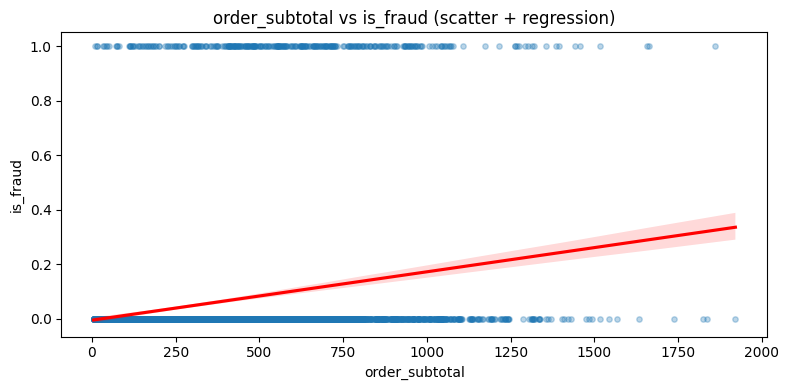

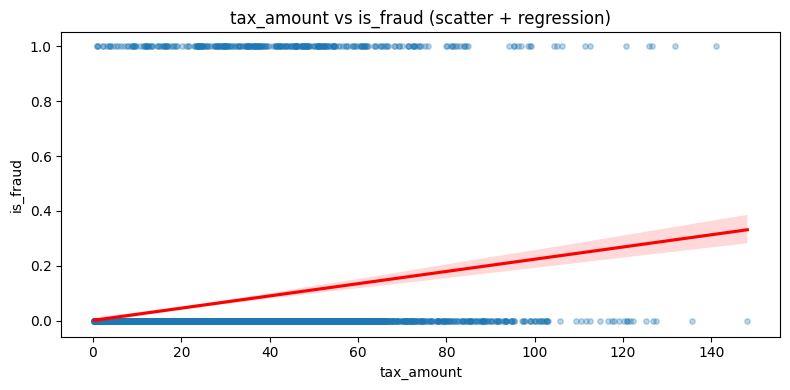

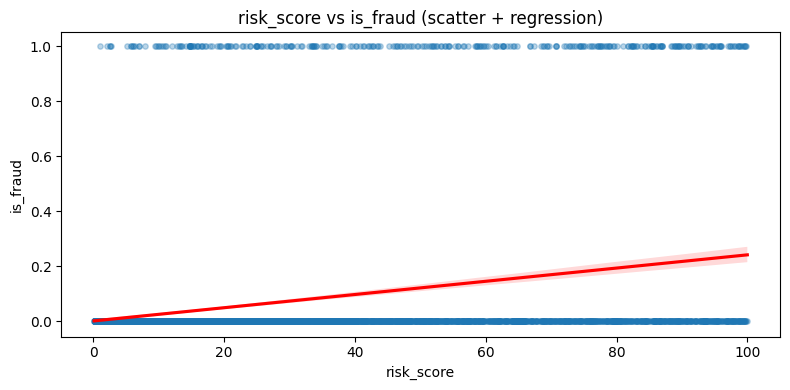

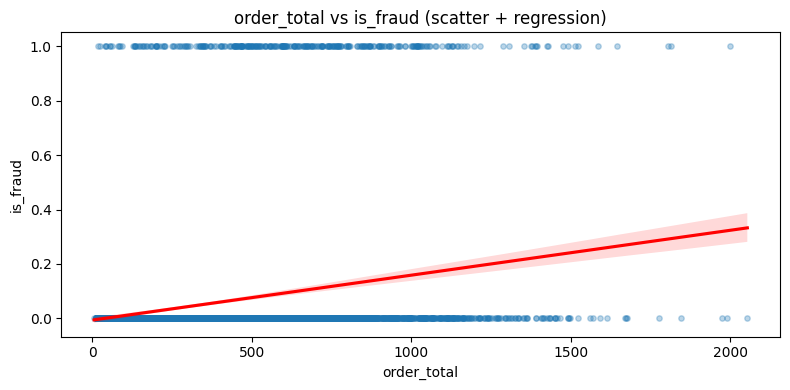

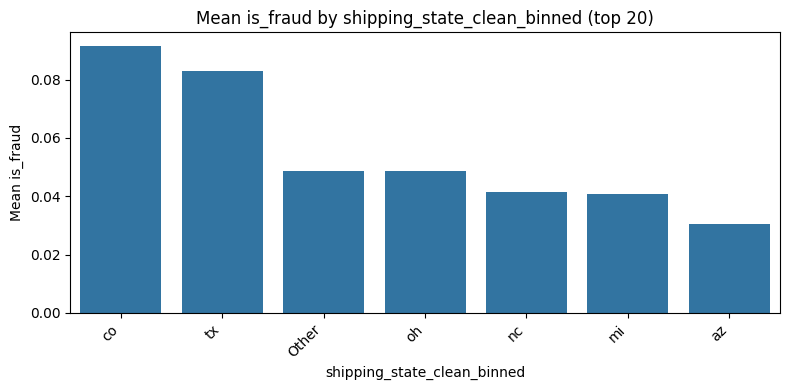

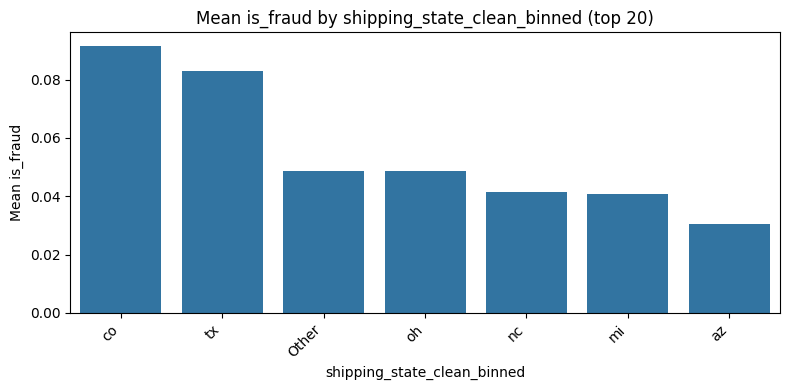

In [89]:
# Create bivariate visualizations for your most significant features
# Assumes you already computed `biv` (bivariate stats) and set `LABEL`

TOP_N = 6  # how many features to plot (adjust)

if "biv" not in globals():
    raise NameError("Run the bivariate stats cell first so `biv` exists.")

if "LABEL" not in globals():
    raise NameError("Set `LABEL` first (e.g., LABEL = 'is_fraud').")

label = LABEL

def _is_numeric(series):
    return pd.api.types.is_numeric_dtype(series)

# take top N non-null p-values
plot_features = (
    biv.dropna(subset=["p"])
    .sort_values("p", ascending=True)
    .head(TOP_N)["feature"]
    .tolist()
)

for feat in plot_features:
    x = df[feat]
    y = df[label]

    # Drop NAs for plotting
    plot_df = df[[feat, label]].dropna()
    if plot_df.empty:
        continue

    x_is_num = _is_numeric(plot_df[feat])
    y_is_num = _is_numeric(plot_df[label])

    plt.figure(figsize=(8, 4))

    # Numeric feature vs numeric label
    if x_is_num and y_is_num:
        sns.regplot(data=plot_df, x=feat, y=label, scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"})
        plt.title(f"{feat} vs {label} (scatter + regression)")

    # Categorical feature vs numeric label: mean(label) per category
    elif (not x_is_num) and y_is_num:
        # use binned version if available to keep readable
        feat_plot = f"{feat}_binned" if f"{feat}_binned" in df.columns else feat
        plot_df2 = df[[feat_plot, label]].dropna()
        means = (
            plot_df2.groupby(feat_plot)[label]
            .mean()
            .sort_values(ascending=False)
            .head(20)
        )
        sns.barplot(x=means.index.astype(str), y=means.values)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(f"Mean {label}")
        plt.title(f"Mean {label} by {feat_plot} (top 20)")

    # Categorical feature vs categorical label
    elif (not x_is_num) and (not y_is_num):
        feat_plot = f"{feat}_binned" if f"{feat}_binned" in df.columns else feat
        plot_df2 = df[[feat_plot, label]].dropna()
        sns.countplot(data=plot_df2, x=feat_plot, hue=label)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"{feat_plot} vs {label} (grouped counts)")

    # Numeric feature vs categorical label
    else:
        sns.boxplot(data=plot_df, x=label, y=feat)
        plt.title(f"{feat} by {label} (box plot)")

    plt.tight_layout()
    plt.show()


---
## Section 6 — Define Your Modeling Goal

Before building any model, answer two questions. Your answers determine which sections to follow next.

---

### Question 1: Causal (Explanatory) or Predictive?

| Goal | Definition | When to use |
|------|-----------|-------------|
| **Causal / Explanatory** | Understand *why* outcomes happen. Interpret coefficients. Trust statistical significance. | You want to explain what drives the outcome (e.g., "What causes sales to increase?") |
| **Predictive** | Maximize accuracy on new, unseen data. Generalization matters more than interpretability. | You want to forecast future outcomes (e.g., "Will this customer churn?") |

→ **Causal with numeric label** → follow **Section 7A** (MLR + Diagnostics)  
→ **Causal with categorical label** → follow **Section 7B** (Logistic Regression)  
→ **Predictive with numeric label** → follow **Section 8A** (Linear Regression + Decision Tree Regressor)  
→ **Predictive with categorical label** → follow **Section 8B** (Decision Tree Classifier + Ensemble Methods)

---

### Question 2: What is the data type of your label?

- **Numeric** (continuous or count): e.g., price, revenue, temperature → regression models
- **Categorical** (two classes): e.g., yes/no, fraud/not-fraud → binary classification
- **Categorical** (3+ classes): e.g., Active/Probation/Terminated → multi-class classification

---

> **Note:** You can follow multiple paths if you want to compare causal and predictive approaches, or if you want to try both regression and classification model families. Always end with **Section 9** (Ch. 15) to evaluate and tune your final model.


---
## Section 7A — Causal Modeling: Numeric Label (Multiple Linear Regression)
*(Chapters 9 & 10)*

Use this section when your **goal is explanation/causation** and your **label is numeric**. MLR produces interpretable coefficients that tell you the magnitude and direction of each feature's effect on the outcome, *holding all other features constant*.

> **Key principle:** In causal modeling, you use *all available data* — you do **not** split into train/test sets. The goal is the most reliable coefficient estimates, not generalization to new data.

---

### 7A.1 Prepare Data for MLR

Steps to prepare the cleaned DataFrame for `statsmodels` OLS:

1. **Remove rows where the label is missing** — you cannot train without the outcome
2. **Separate label (`y`) and features (`X`)** — drop the label column from `X`
3. **Dummy-code all categorical features** — use `pd.get_dummies(X, drop_first=True)` to avoid perfect multicollinearity
4. **Convert all columns to numeric** — boolean columns should be cast to `int`; verify with `X.dtypes`
5. **Add a constant term** — `statsmodels` requires an explicit intercept column (`sm.add_constant()`)

Print the shape of `X` and `y` after each transformation to verify correctness.

In [90]:
# # 1. Remove rows with missing label
# df_model = df.dropna(subset=[LABEL]).copy()

# # 2. Separate label and features
# y = df_model[LABEL]
# X = df_model.drop(columns=[LABEL])

# # 3. Dummy-code categorical features
# X = pd.get_dummies(X, drop_first=True)

# # 4. Ensure all features are numeric
# X = X.astype(float)

# # 5. Add constant for statsmodels intercept
# X_const = sm.add_constant(X)

# print("y shape:", y.shape)
# print("X shape:", X.shape)


### 7A.2 Build the Initial MLR Model

Fit an OLS (Ordinary Least Squares) regression using `statsmodels`. The model summary provides everything needed to assess model fit and interpret coefficients.

**Key statistics to read from the summary:**
- **R²** — proportion of variance in the label explained by the model (higher is better)
- **Adj. R²** — R² penalized for the number of predictors; better for comparing models with different feature counts
- **F-statistic / Prob(F)** — tests whether the model as a whole is statistically significant
- **Coefficients** — the estimated effect of each feature on the label
- **P>|t|** — p-value for each coefficient; values < 0.05 are statistically significant

In [91]:
# results = sm.OLS(y, X_const).fit()
# print(results.summary())


### 7A.3 Identify Significant Features & Calculate In-Sample Error

Extract the features with statistically significant p-values and compute in-sample prediction error metrics.

- **MAE (Mean Absolute Error):** average absolute difference between actual and predicted values — easy to interpret in the same units as the label
- **RMSE (Root Mean Squared Error):** penalizes large errors more heavily than MAE — sensitive to outliers

These are **in-sample** metrics (computed on the same data used to fit the model). They reflect how well the model fits the training data, not how well it will generalize. Actual out-of-sample performance is assessed in Section 8A.

In [92]:
# # Statistically significant features (p < 0.05), excluding the constant
# sig_features = results.pvalues[results.pvalues < 0.05].drop('const', errors='ignore')
# print(f"Significant features ({len(sig_features)}):")
# print(sig_features.sort_values())

# # In-sample error metrics
# y_pred_insample = results.fittedvalues
# mae = mean_absolute_error(y, y_pred_insample)
# rmse = np.sqrt(mean_squared_error(y, y_pred_insample))
# print(f"
# In-Sample MAE:  {mae:,.2f}")
# print(f"In-Sample RMSE: {rmse:,.2f}")


### 7A.4 Interpret Coefficients

Each coefficient tells you: *"Holding all other variables constant, a one-unit increase in this feature is associated with a [coefficient value] change in the label."*

**Numeric features:** interpret directly in the label's units (e.g., "each additional square foot adds $X to the sale price").

**Dummy-coded categorical features:** interpret relative to the *reference category* (the category dropped by `drop_first=True`). For example, if `CentralAir_Y` has a coefficient of $5,000, it means homes *with* central air sell for $5,000 more than homes *without* it, on average.

Extract and print the coefficient, standard error, t-statistic, and p-value for your key features of interest.

In [93]:
# # Replace 'feature_name' with the actual feature name you want to interpret
# feature_of_interest = 'feature_name'

# coef_row = results.params[feature_of_interest]
# se_row   = results.bse[feature_of_interest]
# t_row    = results.tvalues[feature_of_interest]
# p_row    = results.pvalues[feature_of_interest]

# print(f"Feature:         {feature_of_interest}")
# print(f"Coefficient:     {coef_row:.4f}")
# print(f"Std Error:       {se_row:.4f}")
# print(f"t-statistic:     {t_row:.4f}")
# print(f"p-value:         {p_row:.4f}")

# # Write your plain-language interpretation here:
# print("\nInterpretation: ...")


---
### 7A.5 MLR Diagnostics: Test Label Normality
*(Chapter 10)*

MLR assumes the label (and residuals) are approximately normally distributed. Check this before trusting your coefficients.

1. Calculate the **skewness** of your label — values with |skew| > 1 suggest a transformation may help
2. Plot a **histogram** of the label
3. Test multiple transformations and compare their skewness:
   - Natural log: `np.log(y)` (only valid for positive values)
   - Square root: `np.sqrt(y)` (only valid for non-negative values)
   - Box-Cox: use `PowerTransformer(method='box-cox')` from sklearn

If the log-transformed label has significantly lower skewness, consider using it for modeling going forward.

In [94]:
# print(f"Label skewness (raw):    {y.skew():.4f}")
# print(f"Label skewness (log):    {np.log(y).skew():.4f}")
# print(f"Label skewness (sqrt):   {np.sqrt(y).skew():.4f}")

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].hist(y, bins=40, edgecolor='black')
# axes[0].set_title('Label Distribution (Raw)')
# axes[1].hist(np.log(y), bins=40, edgecolor='black', color='steelblue')
# axes[1].set_title('Label Distribution (Log-Transformed)')
# plt.tight_layout()
# plt.show()


### 7A.6 MLR Diagnostics: Test Residual Normality

Even if the label is not normally distributed, the **residuals** (errors = actual − predicted) should be approximately normal for valid inference.

1. Extract residuals: `results.resid`
2. Run the **Omnibus normality test** — a p-value > 0.05 suggests residuals are approximately normal
3. Create a residual **histogram with KDE overlay**
4. Create a **Q-Q plot** (quantile-quantile): if points fall along the diagonal, residuals are approximately normal

In [95]:
# residuals = results.resid

# # Omnibus test
# omni_stat, omni_p = omni_normtest(residuals)
# print(f"Omnibus test: stat={omni_stat:.4f}, p-value={omni_p:.6f}")
# print("(p > 0.05 suggests residuals are approximately normal)")

# # Histogram + Q-Q plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].hist(residuals, bins=40, edgecolor='black', color='coral')
# axes[0].set_title('Residual Distribution')
# axes[0].set_xlabel('Residual')

# stats.probplot(residuals, dist='norm', plot=axes[1])
# axes[1].set_title('Q-Q Plot of Residuals')
# plt.tight_layout()
# plt.show()


### 7A.7 MLR Diagnostics: Detect Multicollinearity with VIF

**Multicollinearity** occurs when features are highly correlated with each other. It inflates standard errors, making coefficient estimates unreliable even if R² is high.

**Variance Inflation Factor (VIF):**
- VIF = 1: no correlation with other features
- VIF 1–3: low correlation (acceptable)
- VIF ≥ 3: problematic multicollinearity — consider removing the feature

Steps:
1. Calculate VIF for every feature (excluding the constant)
2. Create a sorted DataFrame of feature names and VIF values
3. Identify and remove features with VIF ≥ 3
4. Rebuild the model with the refined feature set and compare R² before/after

In [96]:
# # Calculate VIF for each feature
# vif_data = pd.DataFrame()
# vif_data['Feature'] = X_const.columns
# vif_data['VIF'] = [variance_inflation_factor(X_const.values, i)
#                    for i in range(X_const.shape[1])]
# vif_data = vif_data[vif_data['Feature'] != 'const']
# vif_data = vif_data.sort_values('VIF', ascending=False)

# print(f"Features with VIF >= 3: {(vif_data['VIF'] >= 3).sum()}")
# print(vif_data.head(20))


In [97]:
# # Remove high-VIF features and rebuild the model
# high_vif_features = vif_data[vif_data['VIF'] >= 3]['Feature'].tolist()
# X_refined = X.drop(columns=high_vif_features, errors='ignore')
# X_refined_const = sm.add_constant(X_refined)

# results_refined = sm.OLS(y, X_refined_const).fit()
# print(f"Original R²: {results.rsquared:.4f}  |  Refined R²: {results_refined.rsquared:.4f}")
# print(f"Original Adj. R²: {results.rsquared_adj:.4f}  |  Refined Adj. R²: {results_refined.rsquared_adj:.4f}")


### 7A.8 MLR Diagnostics: Residual Analysis (Linearity & Homoscedasticity)

Plot residuals vs. fitted values to check two critical assumptions:

- **Linearity:** Residuals should be randomly scattered around zero. Curved patterns suggest non-linear relationships that the model is missing.
- **Homoscedasticity:** The spread of residuals should be constant across all fitted values. A funnel shape (increasing spread) indicates heteroscedasticity, which undermines standard errors.

A well-behaved plot looks like a random cloud centered on the horizontal zero line.

In [98]:
# fitted = results_refined.fittedvalues
# resid  = results_refined.resid

# plt.figure(figsize=(9, 5))
# plt.scatter(fitted, resid, alpha=0.4, s=10)
# plt.axhline(0, color='red', linewidth=1.2, linestyle='--')
# plt.xlabel('Fitted Values')
# plt.ylabel('Residuals')
# plt.title('Residuals vs. Fitted Values')
# plt.tight_layout()
# plt.show()

# print(f"Mean of residuals: {resid.mean():.4f}  (should be ~0)")
# print(f"Std of residuals:  {resid.std():.4f}")


### 7A.9 MLR Diagnostics: Feature Transformations & Interaction Terms

If the residuals vs. fitted plot shows curvature, or if you have domain knowledge suggesting non-linear effects, add **polynomial** or **interaction** terms.

**Polynomial terms** (for non-linear relationships):
- Create `feature_sq = feature ** 2` and add it alongside the original feature
- Both the original and squared term must be kept together
- Do not remove polynomial features due to high VIF — the high VIF between a feature and its square is expected and acceptable

**Interaction terms** (when the effect of one feature depends on another):
- Create `interaction = feature_A * feature_B`
- Add this to the feature set and check its statistical significance (p-value)

After adding transformations:
1. Rebuild the model
2. Re-check VIF (excluding polynomial term pairs)
3. Report the new R², Adj. R², and Omnibus p-value
4. Compare to the model without transformations

In [99]:
# # Example: Add a squared term for a numeric feature
# # X_refined['feature_sq'] = X_refined['feature_name'] ** 2

# # Example: Add an interaction term between two features
# # X_refined['interaction_AB'] = X_refined['feature_A'] * X_refined['feature_B']

# # Rebuild model after transformations
# X_final_const = sm.add_constant(X_refined)
# results_final = sm.OLS(y, X_final_const).fit()
# print(results_final.summary())


### 7A.10 Final Causal Model Summary

Summarize the final causal (explanatory) model. This model is now suitable for making data-driven business decisions based on reliable coefficient interpretation.

Print:
- Final R² and Adjusted R²
- Number of features
- Top statistically significant features with their coefficients
- A plain-language summary of your most important findings

In [100]:
# print("=" * 60)
# print("FINAL CAUSAL MODEL SUMMARY")
# print("=" * 60)
# print(f"R²:            {results_final.rsquared:.4f}")
# print(f"Adjusted R²:   {results_final.rsquared_adj:.4f}")
# print(f"Observations:  {int(results_final.nobs)}")
# print(f"Features:      {results_final.df_model:.0f}")
# print()
# print("Top Significant Features (p < 0.05):")
# sig = results_final.pvalues[results_final.pvalues < 0.05].drop('const', errors='ignore')
# top = pd.DataFrame({'Coefficient': results_final.params, 'p-value': results_final.pvalues})
# print(top[top['p-value'] < 0.05].sort_values('p-value').head(15))


---
## Section 7B — Causal Modeling: Categorical Label (Logistic Regression)
*(Chapter 9 / 10 concepts applied to classification)*

Use this section when your **goal is explanation** and your **label is categorical** (typically binary: two classes). Logistic regression is the standard causal model for categorical outcomes — its coefficients can be converted to **odds ratios** for intuitive interpretation.

> **Key principle:** Same as Section 7A — use all available data, no train/test split. The goal is reliable coefficient estimates.

---

### 7B.1 Prepare Data for Logistic Regression

1. Remove rows where the label is missing
2. Ensure the label is binary (0/1 or True/False) — encode if needed
3. Separate label (`y`) and features (`X`)
4. Dummy-code categorical features with `drop_first=True`
5. Add a constant using `sm.add_constant()`

In [101]:
# # 1. Remove rows with missing label
# df_logit = df.dropna(subset=[LABEL]).copy()

# # 2. Encode binary label to 0/1 if needed
# # Example: df_logit[LABEL] = (df_logit[LABEL] == 'positive_class_value').astype(int)

# y_cat = df_logit[LABEL]
# X_cat = df_logit.drop(columns=[LABEL])

# # 3. Dummy-code categoricals
# X_cat = pd.get_dummies(X_cat, drop_first=True).astype(float)

# # 4. Add constant
# X_cat_const = sm.add_constant(X_cat)

# print("Label distribution:")
# print(y_cat.value_counts(normalize=True).round(3))


### 7B.2 Build the Logistic Regression Model

Fit a logistic regression model using `statsmodels.Logit`. The model summary outputs:
- **Log-likelihood** — higher (less negative) is better
- **Pseudo R²** (McFadden) — rough analog to R²; values > 0.2 are considered good for logistic regression
- **Coefficients** — the log-odds effect of each feature
- **P>|z|** — p-value for each coefficient

In [102]:
# logit_results = sm.Logit(y_cat, X_cat_const).fit(maxiter=200)
# print(logit_results.summary())


### 7B.3 Interpret Odds Ratios

Logistic regression coefficients are in **log-odds** units, which are hard to interpret directly. Exponentiate them to get **odds ratios**:

- **Odds ratio > 1:** the feature *increases* the probability of the positive outcome
- **Odds ratio < 1:** the feature *decreases* the probability
- **Odds ratio = 1:** the feature has no effect

Example interpretation: an odds ratio of 2.5 for a binary feature means that group has 2.5× the odds of the positive outcome compared to the reference group.

In [103]:
# # Compute odds ratios and confidence intervals
# odds_ratios = pd.DataFrame({
#     'Odds Ratio':  np.exp(logit_results.params),
#     'CI Lower':    np.exp(logit_results.conf_int()[0]),
#     'CI Upper':    np.exp(logit_results.conf_int()[1]),
#     'p-value':     logit_results.pvalues
# }).drop('const', errors='ignore')

# odds_ratios = odds_ratios.sort_values('p-value')
# print(odds_ratios[odds_ratios['p-value'] < 0.05])


### 7B.4 Assess Model Fit (In-Sample Classification Metrics)

Evaluate how well the logistic model classifies observations in-sample. Use a 0.5 probability threshold for initial assessment, but adjust if the classes are imbalanced.

In [104]:
# y_proba_logit = logit_results.predict(X_cat_const)
# y_pred_logit  = (y_proba_logit >= 0.5).astype(int)

# print(f"Accuracy:  {accuracy_score(y_cat, y_pred_logit):.4f}")
# print(f"Precision: {precision_score(y_cat, y_pred_logit):.4f}")
# print(f"Recall:    {recall_score(y_cat, y_pred_logit):.4f}")
# print(f"F1 Score:  {f1_score(y_cat, y_pred_logit):.4f}")

# cm = confusion_matrix(y_cat, y_pred_logit)
# disp = ConfusionMatrixDisplay(cm)
# disp.plot(cmap='Blues')
# plt.title('Logistic Regression (Causal) — Confusion Matrix')
# plt.show()


---
## Section 8A — Predictive Modeling: Numeric Label
*(Chapters 11 & 12)*

Use this section when your **goal is prediction** and your **label is numeric**. The key difference from causal modeling: here we split into **train and test sets** so we can measure how well the model generalizes to unseen data.

> **Golden rule of predictive modeling:** The test set is locked away and touched only once — for final evaluation. Never use test data during model building or selection.

---

### 8A.1 Train/Test Split

Split the cleaned data into training (80%) and testing (20%) sets. Preprocessing will be performed inside an sklearn Pipeline, fitted on training data only, to prevent data leakage.

In [105]:
# # Separate label and features
# df_pred = df.dropna(subset=[LABEL]).copy()
# y_pred = df_pred[LABEL]
# X_pred = df_pred.drop(columns=[LABEL])

# # Train/test split — test set is frozen until final evaluation
# X_train, X_test, y_train, y_test = train_test_split(
#     X_pred, y_pred, test_size=0.20, random_state=42
# )

# print(f"Training set: {X_train.shape[0]} rows")
# print(f"Test set:     {X_test.shape[0]} rows")


### 8A.2 Build a Preprocessing Pipeline

Use sklearn `Pipeline` and `ColumnTransformer` so that:
- All imputation and scaling statistics are learned from **training data only**
- The same transformations are applied consistently to test data
- The pipeline can be used directly for predicting on new cases

**For numeric features:** impute missing values with the median, then standardize with `StandardScaler`  
**For categorical features:** impute with the most frequent value, then one-hot encode with `handle_unknown='ignore'`

In [106]:
# # Identify numeric and categorical features from training data only
# numeric_features    = X_train.select_dtypes(include=['number']).columns.tolist()
# categorical_features = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# print(f"Numeric features:     {len(numeric_features)}")
# print(f"Categorical features: {len(categorical_features)}")

# # Preprocessing pipelines
# numeric_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler',  StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ('num', numeric_transformer,    numeric_features),
#     ('cat', categorical_transformer, categorical_features)
# ])


### 8A.3 Linear Regression (Predictive)

Fit a Linear Regression model inside the preprocessing pipeline. Evaluate on **both training and test sets** to detect overfitting.

**Key metrics:**
- **R²** — proportion of variance explained (1.0 is perfect)
- **MAE** — average absolute prediction error (in label units)
- **RMSE** — root mean squared error (penalizes large errors more; same units as label)

**Signs of overfitting:** training metrics are substantially better than test metrics.

In [107]:
# lr_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model',        LinearRegression())
# ])

# lr_pipeline.fit(X_train, y_train)

# y_train_pred = lr_pipeline.predict(X_train)
# y_test_pred  = lr_pipeline.predict(X_test)

# print("── Linear Regression ────────────────────────────────")
# print(f"  Train R²:   {r2_score(y_train, y_train_pred):.4f}")
# print(f"  Test  R²:   {r2_score(y_test,  y_test_pred):.4f}")
# print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):,.2f}")
# print(f"  Test  RMSE: {np.sqrt(mean_squared_error(y_test,  y_test_pred)):,.2f}")
# print(f"  Train MAE:  {mean_absolute_error(y_train, y_train_pred):,.2f}")
# print(f"  Test  MAE:  {mean_absolute_error(y_test,  y_test_pred):,.2f}")


### 8A.4 Visualize Predictions vs. Actual Values

Create scatter plots comparing predicted vs. actual values for both train and test sets. The diagonal line represents perfect predictions. Points close to the diagonal indicate accurate predictions; systematic curvature suggests a non-linear relationship that the model is missing.

In [108]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# for ax, y_true, y_hat, title in zip(
#         axes,
#         [y_train, y_test],
#         [y_train_pred, y_test_pred],
#         ['Training Set', 'Test Set']):
#     ax.scatter(y_true, y_hat, alpha=0.3, s=10)
#     lims = [min(y_true.min(), y_hat.min()), max(y_true.max(), y_hat.max())]
#     ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
#     ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
#     ax.set_title(f'Predicted vs. Actual — {title}')
#     ax.legend()
# plt.tight_layout(); plt.show()


### 8A.5 Greedy Backward Feature Removal

Greedily remove one feature at a time to find the optimal subset that minimizes validation-set error. This reduces overfitting and model complexity.

**Algorithm:**
1. Create a validation split from the training set (e.g., 75/25)
2. Start with all features
3. At each step, try removing each remaining feature and choose the removal that produces the lowest validation RMSE
4. Record the step, the removed feature, and the resulting metrics
5. Continue until a minimum number of features remain
6. Plot validation RMSE vs. number of features and identify the optimal stopping point
7. Retrain the final model on the full training set using only the optimal features

In [109]:
# # Split training data for feature selection (validation set)
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train, test_size=0.25, random_state=42
# )

# def make_regression_model(features):
#     num_f = [f for f in numeric_features    if f in features]
#     cat_f = [f for f in categorical_features if f in features]
#     prep  = ColumnTransformer([
#         ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
#                           ('scl', StandardScaler())]), num_f),
#         ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
#                           ('enc', OneHotEncoder(handle_unknown='ignore',
#                                                 drop='first', sparse_output=False))]), cat_f)
#     ], remainder='drop')
#     return Pipeline([('prep', prep), ('model', LinearRegression())])

# selected = list(X_train.columns)
# removal_trace = []

# while len(selected) > 5:   # stop at 5 features (adjust as needed)
#     best_rmse, best_feature = np.inf, None
#     for feat in selected:
#         trial = [f for f in selected if f != feat]
#         if len(trial) == 0:
#             continue
#         pipe = make_regression_model(trial)
#         pipe.fit(X_tr[trial], y_tr)
#         rmse = np.sqrt(mean_squared_error(y_val, pipe.predict(X_val[trial])))
#         if rmse < best_rmse:
#             best_rmse, best_feature = rmse, feat
#     selected.remove(best_feature)
#     mae  = mean_absolute_error(y_val, make_regression_model(selected)
#                                       .fit(X_tr[selected], y_tr)
#                                       .predict(X_val[selected]))
#     removal_trace.append({'step': len(removal_trace)+1, 'removed': best_feature,
#                           'n_features': len(selected), 'val_rmse': best_rmse, 'val_mae': mae})
#     print(f"Step {len(removal_trace):3d} | Removed: {best_feature:<40} | Val RMSE: {best_rmse:,.2f}")

# removal_df = pd.DataFrame(removal_trace)


In [110]:
# # Plot validation RMSE vs. number of features
# plt.figure(figsize=(10, 5))
# plt.plot(removal_df['n_features'], removal_df['val_rmse'], marker='o', markersize=4)
# plt.xlabel('Number of Features Remaining')
# plt.ylabel('Validation RMSE')
# plt.title('Greedy Backward Feature Removal')
# plt.gca().invert_xaxis()
# plt.tight_layout(); plt.show()

# # Select optimal feature count (minimum validation RMSE)
# optimal_row      = removal_df.loc[removal_df['val_rmse'].idxmin()]
# optimal_n        = int(optimal_row['n_features'])
# optimal_step     = int(optimal_row['step'])
# features_removed = removal_df.loc[:optimal_step-1, 'removed'].tolist()
# optimal_features = [f for f in X_train.columns if f not in features_removed]

# print(f"Optimal number of features: {optimal_n}")
# print(f"Optimal validation RMSE:    {optimal_row['val_rmse']:,.2f}")


In [111]:
# # Retrain the optimal model on the full training set
# optimal_model = make_regression_model(optimal_features)
# optimal_model.fit(X_train[optimal_features], y_train)

# opt_test_rmse = np.sqrt(mean_squared_error(y_test, optimal_model.predict(X_test[optimal_features])))
# opt_test_mae  = mean_absolute_error(y_test, optimal_model.predict(X_test[optimal_features]))
# opt_test_r2   = r2_score(y_test, optimal_model.predict(X_test[optimal_features]))

# print(f"Optimal Model — Test RMSE: {opt_test_rmse:,.2f}")
# print(f"Optimal Model — Test MAE:  {opt_test_mae:,.2f}")
# print(f"Optimal Model — Test R²:   {opt_test_r2:.4f}")

# # Compare to baseline (always predicting the training mean)
# baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean())))
# pct_improvement = ((baseline_rmse - opt_test_rmse) / baseline_rmse) * 100
# print(f"
# Baseline RMSE:   {baseline_rmse:,.2f}")
# print(f"% Improvement:   {pct_improvement:.2f}%")


---
### 8A.6 Decision Tree Regressor
*(Chapter 12)*

Decision trees can capture **non-linear patterns and feature interactions** automatically, without requiring polynomial terms or manual feature engineering. However, they are prone to overfitting when left unrestricted.

> **Note:** Decision trees do **not** require feature scaling. The preprocessing pipeline still handles missing value imputation and categorical encoding, but you can omit the `StandardScaler` step.

**Build the basic (unrestricted) decision tree and examine its structure:**

In [112]:
# # Preprocessing without scaling (trees don't need it)
# preprocessor_tree = ColumnTransformer(transformers=[
#     ('num', SimpleImputer(strategy='median'), numeric_features),
#     ('cat', Pipeline([
#         ('imp', SimpleImputer(strategy='most_frequent')),
#         ('enc', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
#     ]), categorical_features)
# ])

# tree_basic = Pipeline([
#     ('preprocessor', preprocessor_tree),
#     ('model', DecisionTreeRegressor(random_state=42))
# ])

# tree_basic.fit(X_train, y_train)

# train_rmse_tree = np.sqrt(mean_squared_error(y_train, tree_basic.predict(X_train)))
# test_rmse_tree  = np.sqrt(mean_squared_error(y_test,  tree_basic.predict(X_test)))

# print(f"Tree depth:      {tree_basic.named_steps['model'].tree_.max_depth}")
# print(f"Total nodes:     {tree_basic.named_steps['model'].tree_.node_count}")
# print(f"Train RMSE:      {train_rmse_tree:,.2f}")
# print(f"Test  RMSE:      {test_rmse_tree:,.2f}")
# print(f"Overfitting gap: {test_rmse_tree - train_rmse_tree:,.2f}")


### 8A.7 Feature Importance (Decision Tree)

Decision trees compute feature importance based on how much each feature reduces prediction error across all splits. This is a useful diagnostic even if you don't end up using the tree as your final model.

In [113]:
# # Get feature names after one-hot encoding
# try:
#     feature_names = preprocessor_tree.get_feature_names_out()
# except:
#     feature_names = [f'feature_{i}' for i in range(len(tree_basic.named_steps['model'].feature_importances_))]

# importances = pd.Series(
#     tree_basic.named_steps['model'].feature_importances_, index=feature_names
# ).sort_values(ascending=False)

# print("Top 10 Most Important Features:")
# print(importances.head(10))

# importances.head(15).plot(kind='barh', figsize=(9, 6))
# plt.xlabel('Importance Score')
# plt.title('Decision Tree — Feature Importances')
# plt.gca().invert_yaxis()
# plt.tight_layout(); plt.show()


### 8A.8 Regularize the Decision Tree

Control overfitting with hyperparameters:
- `max_depth` — maximum number of levels in the tree (limits complexity)
- `min_samples_leaf` — minimum number of samples required in a leaf node (prevents very specific splits)

**Find the optimal depth by testing a range of values and plotting training vs. test RMSE:**

In [114]:
# depths      = [2, 3, 4, 5, 6, 8, 10, 15, 20]
# depth_results = []

# for d in depths:
#     pipe = Pipeline([
#         ('preprocessor', preprocessor_tree),
#         ('model', DecisionTreeRegressor(max_depth=d, min_samples_leaf=20, random_state=42))
#     ])
#     pipe.fit(X_train, y_train)
#     depth_results.append({
#         'max_depth':  d,
#         'train_rmse': np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))),
#         'test_rmse':  np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test))),
#         'train_mae':  mean_absolute_error(y_train, pipe.predict(X_train)),
#         'test_mae':   mean_absolute_error(y_test,  pipe.predict(X_test))
#     })

# depth_df = pd.DataFrame(depth_results)
# print(depth_df.to_string(index=False))

# plt.figure(figsize=(9, 5))
# plt.plot(depth_df['max_depth'], depth_df['train_rmse'], marker='o', label='Train RMSE')
# plt.plot(depth_df['max_depth'], depth_df['test_rmse'],  marker='s', label='Test RMSE')
# plt.xlabel('Max Depth'); plt.ylabel('RMSE')
# plt.title('Tree Depth vs. RMSE (Train and Test)')
# plt.legend(); plt.tight_layout(); plt.show()


### 8A.9 Model Comparison — Numeric Predictive Models

Compare all numeric predictive models you've built. The test RMSE is the primary metric — it reflects real-world prediction accuracy.

In [115]:
# best_depth = depth_df.loc[depth_df['test_rmse'].idxmin(), 'max_depth']
# best_tree  = Pipeline([
#     ('preprocessor', preprocessor_tree),
#     ('model', DecisionTreeRegressor(max_depth=best_depth, min_samples_leaf=20, random_state=42))
# ])
# best_tree.fit(X_train, y_train)

# comparison = pd.DataFrame([
#     {'Model': 'Linear Regression (all features)',
#      'Test RMSE': np.sqrt(mean_squared_error(y_test, lr_pipeline.predict(X_test))),
#      'Test MAE':  mean_absolute_error(y_test, lr_pipeline.predict(X_test)),
#      'Test R²':   r2_score(y_test, lr_pipeline.predict(X_test))},
#     {'Model': f'Linear Regression (optimal {optimal_n} features)',
#      'Test RMSE': opt_test_rmse, 'Test MAE': opt_test_mae, 'Test R²': opt_test_r2},
#     {'Model': 'Decision Tree (unrestricted)',
#      'Test RMSE': np.sqrt(mean_squared_error(y_test, tree_basic.predict(X_test))),
#      'Test MAE':  mean_absolute_error(y_test, tree_basic.predict(X_test)),
#      'Test R²':   r2_score(y_test, tree_basic.predict(X_test))},
#     {'Model': f'Decision Tree (depth={best_depth}, min_leaf=20)',
#      'Test RMSE': np.sqrt(mean_squared_error(y_test, best_tree.predict(X_test))),
#      'Test MAE':  mean_absolute_error(y_test, best_tree.predict(X_test)),
#      'Test R²':   r2_score(y_test, best_tree.predict(X_test))},
#     {'Model': 'Baseline (predict mean)',
#      'Test RMSE': baseline_rmse, 'Test MAE': mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())),
#      'Test R²': 0.0}
# ]).sort_values('Test RMSE')

# print(comparison.to_string(index=False))


### 8A.10 Predict a New Case

Use the best model to make a prediction on a new, unseen case. Create a one-row DataFrame matching your feature columns, modify specific values to describe the new case, and pass it to the pipeline.

In [116]:
# # Start from a test-set row as a template
# new_case = X_test.iloc[[0]].copy()

# # Modify key features to describe your new case (replace with actual values)
# # new_case['feature_A'] = value_A
# # new_case['feature_B'] = value_B

# # Use the best model to predict (pipeline handles all preprocessing)
# best_model = best_tree   # or optimal_model — whichever performed better
# prediction  = best_model.predict(new_case[best_model.feature_names_in_
#                                           if hasattr(best_model, 'feature_names_in_')
#                                           else new_case.columns])
# print(f"Predicted {LABEL}: {prediction[0]:,.2f}")


---
## Section 8B — Predictive Modeling: Categorical Label
*(Chapters 13 & 14)*

Use this section when your **goal is prediction** and your **label is categorical**. This section covers:
- **Two-class classification** (binary: two outcome categories)
- **Multi-class classification** (three or more outcome categories)
- **Ensemble methods** that combine multiple models for stronger predictions

---

### 8B.1 Prepare the Data for Classification

Steps:
1. Define your label column (categorical/string or 0/1)
2. For **two-class:** ensure the label has exactly two unique values
3. For **multi-class:** review all label values; filter/relabel if needed (see 8B.4)
4. Convert categorical columns that are actually categories (not ordinal numbers) to `object` dtype
5. Drop any alternative label columns that would cause data leakage
6. Create dummy codes for all remaining categorical features
7. Separate label (`y`) and features (`X`)
8. Split into train/test (70/30 is common for classification)

In [117]:
CAT_LABEL = "is_fraud"  # classification label

# Drop rows missing the label (do NOT drop other rows yet)
df_cls = df.dropna(subset=[CAT_LABEL]).copy()

# Ensure binary label (two unique values)
label_vals = df_cls[CAT_LABEL].dropna().unique().tolist()
print("Label unique values:", label_vals)
if len(label_vals) != 2:
    raise ValueError(f"Expected binary label with 2 unique values, got {len(label_vals)}: {label_vals}")

# Optional: drop obvious leakage columns if present
leakage_cols = [
    # add any columns here that directly encode the outcome
]
leakage_cols = [c for c in leakage_cols if c in df_cls.columns]
if leakage_cols:
    print("Dropping potential leakage columns:", leakage_cols)
    df_cls = df_cls.drop(columns=leakage_cols)

# Separate label and RAW features (keep raw for ensemble pipelines)
y_cls = df_cls[CAT_LABEL]
X_cls = df_cls.drop(columns=[CAT_LABEL])

print("X (raw) shape:", X_cls.shape)
print("y shape:", y_cls.shape)
print("Label distribution:")
print(y_cls.value_counts(normalize=True).round(3))

# For the simple 8B.2 tree (non-pipeline), you can create a dummied version.
# IMPORTANT: do NOT overwrite X_cls (raw). Keeping X_cls raw prevents huge dense matrices.
X_cls_dum = pd.get_dummies(X_cls, drop_first=True)
print("X_cls_dum shape (for 8B.2):", X_cls_dum.shape)


Label unique values: [0.0, 1.0]
X (raw) shape: (5000, 52)
y shape: (5000,)
Label distribution:
is_fraud
0.0000   0.9360
1.0000   0.0640
Name: proportion, dtype: float64
X_cls_dum shape (for 8B.2): (5000, 5066)


### 8B.2 Two-Class Decision Tree Classifier

Train a `DecisionTreeClassifier` for binary classification. Unlike regression, classification models predict a **class label** (and optionally a probability).

**Train/test split:**

In [118]:
# Stratified split keeps fraud/non-fraud proportions similar in train/test
# Use the dummied matrix for this simple (non-pipeline) tree section.
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls_dum,
    y_cls,
    test_size=0.30,
    stratify=y_cls,
    random_state=12345,
)

print(f"Train: {X_cls_train.shape[0]} rows  |  Test: {X_cls_test.shape[0]} rows")
print("\nLabel distribution (train):")
print(y_cls_train.value_counts(normalize=True).round(3))
print("\nLabel distribution (test):")
print(y_cls_test.value_counts(normalize=True).round(3))


Train: 3500 rows  |  Test: 1500 rows

Label distribution (train):
is_fraud
0.0000   0.9360
1.0000   0.0640
Name: proportion, dtype: float64

Label distribution (test):
is_fraud
0.0000   0.9370
1.0000   0.0630
Name: proportion, dtype: float64


In [119]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_classifier = DecisionTreeClassifier(random_state=12345)
dt_classifier.fit(X_cls_train, y_cls_train)

y_cls_pred = dt_classifier.predict(X_cls_test)

print(f"Max depth: {dt_classifier.tree_.max_depth}")
print(f"Accuracy:  {accuracy_score(y_cls_test, y_cls_pred):.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_cls_test, y_cls_pred))

print("\nClassification report:")
print(classification_report(y_cls_test, y_cls_pred, zero_division=0))


Max depth: 73
Accuracy:  0.9313

Confusion matrix:
[[1395   10]
 [  93    2]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96      1405
         1.0       0.17      0.02      0.04        95

    accuracy                           0.93      1500
   macro avg       0.55      0.51      0.50      1500
weighted avg       0.89      0.93      0.91      1500



### 8B.3 Evaluate the Two-Class Classifier

Evaluate classification quality using the **confusion matrix** and key metrics:

| Metric | Definition | When to emphasize |
|--------|-----------|-------------------|
| **Accuracy** | % of all predictions that are correct | Balanced classes |
| **Precision** | Of predicted positives, what % are actually positive | When false positives are costly |
| **Recall** | Of actual positives, what % did we catch | When false negatives are costly (e.g., fraud, disease) |
| **F1 Score** | Harmonic mean of precision and recall | Imbalanced classes |

Classes: [0.0, 1.0]
Positive class: 1.0
Accuracy:  0.9313
Precision: 0.1667
Recall:    0.0211
F1 Score:  0.0374


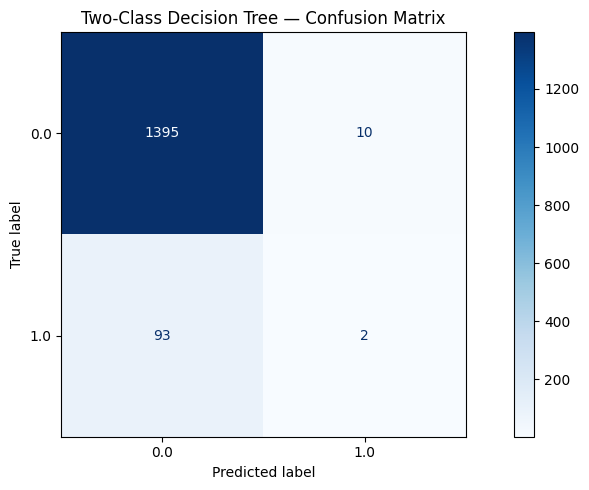

In [120]:
# Pick the positive class (for fraud, we usually treat "1" as positive)
classes = sorted(pd.Series(y_cls_test.dropna().unique()).tolist())
if len(classes) != 2:
    raise ValueError(f"Expected 2 classes for binary classification, got {classes}")

# If numeric, pick the larger value as the positive class; otherwise pick the 2nd sorted class
if all(isinstance(c, (int, float, np.integer, np.floating)) for c in classes):
    positive_class = max(classes)
else:
    positive_class = classes[1]

print("Classes:", classes)
print("Positive class:", positive_class)

print(f"Accuracy:  {accuracy_score(y_cls_test,  y_cls_pred):.4f}")
print(f"Precision: {precision_score(y_cls_test, y_cls_pred, pos_label=positive_class, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_cls_test,    y_cls_pred, pos_label=positive_class, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_cls_test,        y_cls_pred, pos_label=positive_class, zero_division=0):.4f}")

disp = ConfusionMatrixDisplay.from_predictions(y_cls_test, y_cls_pred, cmap='Blues')
disp.ax_.set_title('Two-Class Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()


### 8B.4 Multi-Class Classification

If your label has **three or more categories**, follow these additional steps before modeling:

1. **Explore all label combinations** — print value counts for every label-related column to understand what statuses/classes exist
2. **Filter irrelevant classes** — remove rows with rare or ambiguous classes that don't fit your prediction task
3. **Relabel/merge classes** — consolidate similar statuses into the classes you want to predict
4. **Verify your three (or more) distinct classes** are represented in the data

After relabeling, create a new `df_model` copy for the multi-class model so you preserve the cleaned DataFrame for reference.

In [121]:
# Explore all combinations of label-related columns
# Replace with the actual column names in your dataset
# df.groupby(['label_col1', 'label_col2']).size().reset_index(name='count')

# Filter unwanted classes
# df_multi = df[~df[CAT_LABEL].isin(['ClassToRemove1', 'ClassToRemove2'])].copy()

# Relabel to create desired multi-class categories
# df_multi.loc[df_multi['some_col'] == 'SomeStatus', CAT_LABEL] = 'NewClassName'

# Verify final class distribution
# print(df_multi[CAT_LABEL].value_counts())


### 8B.5 Multi-Class Decision Tree Classifier

Train, evaluate, and compare a `DecisionTreeClassifier` on the multi-class label. Use `average='weighted'` for precision, recall, and F1 when classes are imbalanced — this weights each class's metric by its proportion in the test set.

Number of classes: 2
Accuracy:  0.9313
Precision (weighted): 0.8887
Recall    (weighted): 0.9313
F1        (weighted): 0.9057


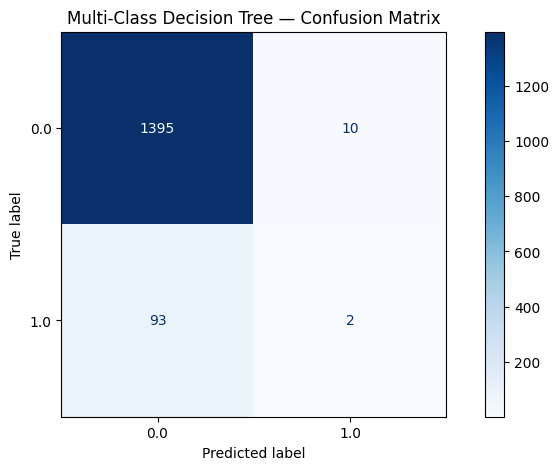

In [122]:
# Replace with your multi-class setup (re-dummy-code if needed for new label)
# X_multi, y_multi = ...
# X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(...)

dt_multi = DecisionTreeClassifier(random_state=12345)
dt_multi.fit(X_cls_train, y_cls_train)   # replace with your multi-class train sets

y_multi_pred = dt_multi.predict(X_cls_test)

print(f"Number of classes: {dt_multi.n_classes_}")
print(f"Accuracy:  {accuracy_score(y_cls_test, y_multi_pred):.4f}")
print(f"Precision (weighted): {precision_score(y_cls_test, y_multi_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall    (weighted): {recall_score(y_cls_test, y_multi_pred,    average='weighted', zero_division=0):.4f}")
print(f"F1        (weighted): {f1_score(y_cls_test,     y_multi_pred,    average='weighted', zero_division=0):.4f}")

disp = ConfusionMatrixDisplay.from_predictions(y_cls_test, y_multi_pred, cmap='Blues')
disp.ax_.set_title('Multi-Class Decision Tree — Confusion Matrix')
plt.show()


---
### 8B.6 Ensemble Methods
*(Chapter 14)*

Ensemble methods combine multiple models to improve predictive performance. Each method reduces a different component of error:

| Method | Strategy | Reduces |
|--------|---------|---------|
| **Bagging** | Average many trees trained on bootstrap samples | Variance |
| **Random Forest** | Bagging + random feature subsets per split | Variance (more) |
| **AdaBoost** | Sequentially reweight misclassified samples | Bias + Variance |
| **Gradient Boosting** | Sequentially fit residuals | Bias + Variance |
| **XGBoost** | Optimized gradient boosting | Bias + Variance |
| **Stacking** | Meta-learner combines diverse base models | Bias + Variance |

Use a **preprocessing pipeline** for all ensemble models to prevent data leakage. Use `random_state=27` for reproducibility. Also use a **stratified** train/test split when class imbalance is present.

In [123]:
# Stratified split to preserve class proportions
X_ens_train, X_ens_test, y_ens_train, y_ens_test = train_test_split(
    X_cls, y_cls, test_size=0.20, stratify=y_cls, random_state=27
)

# Re-identify feature types from training data
num_ens = X_ens_train.select_dtypes(include="number").columns.tolist()
cat_ens = X_ens_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# IMPORTANT: keep one-hot output SPARSE to avoid huge dense matrices (MemoryError)
preprocessor_ens = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    # with_mean=False keeps it compatible with sparse output
                    ("scl", StandardScaler(with_mean=False)),
                ]
            ),
            num_ens,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)),
                ]
            ),
            cat_ens,
        ),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

print(f"Train: {X_ens_train.shape[0]}  |  Test: {X_ens_test.shape[0]}")
print("Class distribution (train):", y_ens_train.value_counts(normalize=True).round(3).to_dict())


Train: 4000  |  Test: 1000
Class distribution (train): {0.0: 0.936, 1.0: 0.064}


#### Baseline Models

Establish single-model baselines before building ensembles. These give you a reference point for measuring improvement.

In [124]:
# Check how many features the preprocessor will create (before training models)
preprocessor_ens.fit(X_ens_train)

try:
    feat_names = preprocessor_ens.get_feature_names_out()
    print("Total engineered features:", len(feat_names))
except Exception as e:
    print("Could not get feature names:", type(e).__name__)

# Breakdown: numeric features + total one-hot features
num_features = getattr(preprocessor_ens, "transformers_", [])[0][2] if hasattr(preprocessor_ens, "transformers_") else []

try:
    ohe = preprocessor_ens.named_transformers_["cat"].named_steps["enc"]
    n_ohe = int(sum(len(cats) for cats in ohe.categories_))
    print("Numeric input cols:", len(num_ens))
    print("Categorical input cols:", len(cat_ens))
    print("One-hot features (sum of categories):", n_ohe)
except Exception as e:
    print("Could not compute one-hot breakdown:", type(e).__name__)


Total engineered features: 28
Could not compute one-hot breakdown: AttributeError


In [125]:
# ── Baselines: fit preprocessor once ─────────────────────────────────────────
X_ens_train_prep = preprocessor_ens.fit_transform(X_ens_train)
X_ens_test_prep  = preprocessor_ens.transform(X_ens_test)

# ── Baseline 1: Single Decision Tree ─────────────────────────────────────────
dt_baseline = DecisionTreeClassifier(max_depth=3, random_state=27)
dt_baseline.fit(X_ens_train_prep, y_ens_train)

dt_pred  = dt_baseline.predict(X_ens_test_prep)
dt_proba = dt_baseline.predict_proba(X_ens_test_prep)

dt_acc  = accuracy_score(y_ens_test, dt_pred)
dt_loss = log_loss(y_ens_test, dt_proba, labels=dt_baseline.classes_)
print(f"Single DT  — Accuracy: {dt_acc:.4f}  |  Log Loss: {dt_loss:.4f}")

# ── Baseline 2: Logistic Regression ───────────────────────────────────────────
lr_baseline = LogisticRegression(max_iter=2000, random_state=27)
lr_baseline.fit(X_ens_train_prep, y_ens_train)

lr_pred  = lr_baseline.predict(X_ens_test_prep)
lr_proba = lr_baseline.predict_proba(X_ens_test_prep)

lr_acc  = accuracy_score(y_ens_test, lr_pred)
lr_loss = log_loss(y_ens_test, lr_proba, labels=lr_baseline.classes_)
print(f"Logistic   — Accuracy: {lr_acc:.4f}  |  Log Loss: {lr_loss:.4f}")

Single DT  — Accuracy: 0.9360  |  Log Loss: 0.2108
Logistic   — Accuracy: 0.9360  |  Log Loss: 0.2073


In [126]:
# ── Bagging Classifier ───────────────────────────────────────────────────────
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    max_samples=0.5,
    random_state=27,
    n_jobs=-1
)
bagging.fit(X_ens_train_prep, y_ens_train)

bag_acc  = accuracy_score(y_ens_test, bagging.predict(X_ens_test_prep))
bag_loss = log_loss(y_ens_test, bagging.predict_proba(X_ens_test_prep))
print(f"Bagging    — Accuracy: {bag_acc:.4f}  |  Log Loss: {bag_loss:.4f}")

Bagging    — Accuracy: 0.9360  |  Log Loss: 0.2093


In [127]:
# ── Random Forest ────────────────────────────────────────────────────────────

# Pre-transform once instead of repeating inside the pipeline
X_ens_train_prep = preprocessor_ens.fit_transform(X_ens_train)
X_ens_test_prep  = preprocessor_ens.transform(X_ens_test)

rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    random_state=27,
    n_jobs=-1
)
rf.fit(X_ens_train_prep, y_ens_train)

rf_proba = rf.predict_proba(X_ens_test_prep)
rf_pred  = rf.predict(X_ens_test_prep)

rf_acc  = accuracy_score(y_ens_test, rf_pred)
rf_loss = log_loss(y_ens_test, rf_proba)
rf_auc  = roc_auc_score(y_ens_test, rf_proba[:, 1])

print(f"Rnd Forest — Accuracy: {rf_acc:.4f}  |  Log Loss: {rf_loss:.4f}  |  ROC AUC: {rf_auc:.4f}")

Rnd Forest — Accuracy: 0.9360  |  Log Loss: 0.3083  |  ROC AUC: 0.7561


#### Random Forest Feature Importance

Extract the feature importances from the trained Random Forest. This tells you which features the forest found most useful across all its trees.

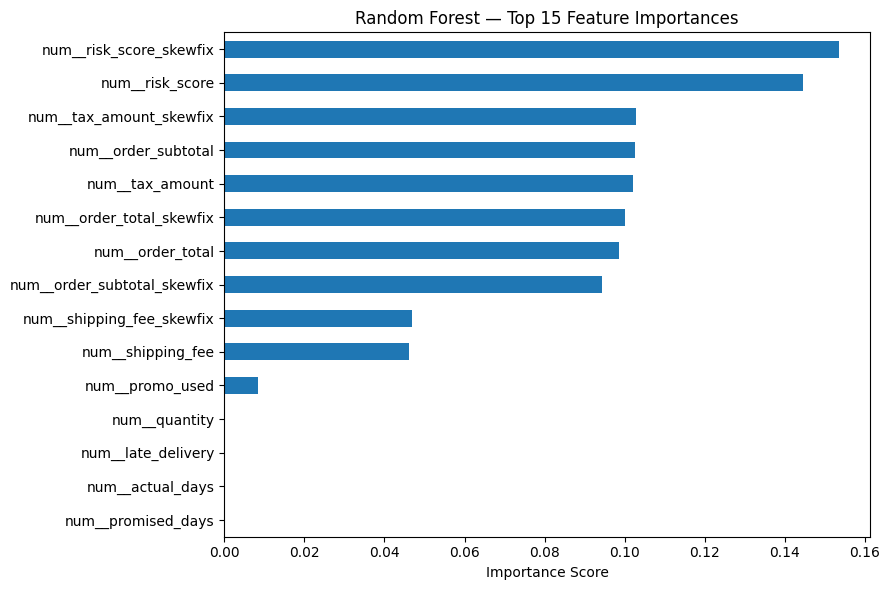

In [128]:
try:
    rf_feature_names = preprocessor_ens.get_feature_names_out()
except:
    rf_feature_names = [f'f_{i}' for i in range(len(rf.feature_importances_))]

rf_importances = pd.Series(
    rf.feature_importances_, index=rf_feature_names
).sort_values(ascending=False)

rf_importances.head(15).plot(kind='barh', figsize=(9, 6))
plt.xlabel('Importance Score')
plt.title('Random Forest — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [129]:
# ── AdaBoost ──────────────────────────────────────────────────────────────────
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=27
)
ada.fit(X_ens_train_prep, y_ens_train)

ada_acc  = accuracy_score(y_ens_test, ada.predict(X_ens_test_prep))
ada_loss = log_loss(y_ens_test, ada.predict_proba(X_ens_test_prep))
print(f"AdaBoost   — Accuracy: {ada_acc:.4f}  |  Log Loss: {ada_loss:.4f}")

AdaBoost   — Accuracy: 0.9360  |  Log Loss: 0.4229


In [130]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=27
)
gb.fit(X_ens_train_prep, y_ens_train)

gb_acc  = accuracy_score(y_ens_test, gb.predict(X_ens_test_prep))
gb_loss = log_loss(y_ens_test, gb.predict_proba(X_ens_test_prep))
print(f"Grad Boost — Accuracy: {gb_acc:.4f}  |  Log Loss: {gb_loss:.4f}")

Grad Boost — Accuracy: 0.9350  |  Log Loss: 0.2148


In [131]:
# ── XGBoost (optional — requires 'pip install xgboost') ───────────────────────
# from xgboost import XGBClassifier
# xgb = Pipeline([
#     ('prep', preprocessor_ens),
#     ('model', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
#                             random_state=27, use_label_encoder=False,
#                             eval_metric='logloss'))
# ])
# xgb.fit(X_ens_train, y_ens_train)
# xgb_acc  = accuracy_score(y_ens_test, xgb.predict(X_ens_test))
# xgb_loss = log_loss(y_ens_test, xgb.predict_proba(X_ens_test))
# print(f"XGBoost    — Accuracy: {xgb_acc:.4f}  |  Log Loss: {xgb_loss:.4f}")


In [132]:
# ── Stacking Classifier ───────────────────────────────────────────────────────
stacking = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=2000, random_state=27)),
        ('rf',  RandomForestClassifier(n_estimators=50, random_state=27)),
        ('knn', KNeighborsClassifier(n_neighbors=15))
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_ens_train_prep, y_ens_train)

stack_acc  = accuracy_score(y_ens_test, stacking.predict(X_ens_test_prep))
stack_loss = log_loss(y_ens_test, stacking.predict_proba(X_ens_test_prep))
print(f"Stacking   — Accuracy: {stack_acc:.4f}  |  Log Loss: {stack_loss:.4f}")

Stacking   — Accuracy: 0.9360  |  Log Loss: 0.2130


### 8B.7 Ensemble Model Comparison

Build a summary table comparing all models on accuracy and log loss. Sort by log loss (ascending) — lower log loss means better probability calibration, which is crucial for threshold-based decisions.

Then generate confusion matrices for the top two models to compare precision and recall for the key class.

In [133]:
results_ens = pd.DataFrame([
    {"Model": "Decision Tree (baseline)", "Accuracy": dt_acc,    "Log Loss": dt_loss},
    {"Model": "Logistic Regression",      "Accuracy": lr_acc,    "Log Loss": lr_loss},
    {"Model": "Bagging",                  "Accuracy": bag_acc,   "Log Loss": bag_loss},
    {"Model": "Random Forest",            "Accuracy": rf_acc,    "Log Loss": rf_loss},
    {"Model": "AdaBoost",                 "Accuracy": ada_acc,   "Log Loss": ada_loss},
    {"Model": "Gradient Boosting",        "Accuracy": gb_acc,    "Log Loss": gb_loss},
    {"Model": "Stacking",                 "Accuracy": stack_acc, "Log Loss": stack_loss},
]).sort_values("Log Loss")

display(results_ens)


,Model,Accuracy,Log Loss
1,Logistic Regression,0.9360,0.2073
2,Bagging,0.9360,0.2093
0,Decision Tree (baseline),0.9360,0.2108
6,Stacking,0.9360,0.2130
5,Gradient Boosting,0.9350,0.2148
3,Random Forest,0.9360,0.3083
4,AdaBoost,0.9360,0.4229


C:\Users\camjw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\camjw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(


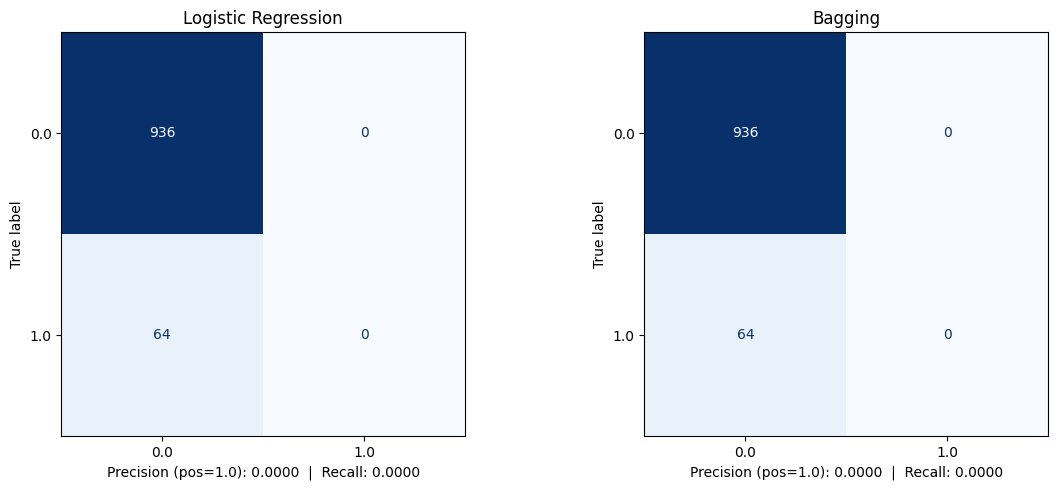

In [134]:
# Confusion matrices for the top 2 models (by lowest log loss)
# Follows the markdown: pick top 2 by log loss, then compare confusion matrices + precision/recall.

if "results_ens" not in globals():
    raise NameError("Run the ensemble results table cell first so `results_ens` exists.")

# Map display names -> fitted pipeline objects (only include ones that exist)
model_map = {}
for name, obj in [
    ("Decision Tree (baseline)", globals().get("dt_baseline")),
    ("Logistic Regression", globals().get("lr_baseline")),
    ("Bagging", globals().get("bagging")),
    ("Random Forest", globals().get("rf")),
    ("AdaBoost", globals().get("ada")),
    ("Gradient Boosting", globals().get("gb")),
    ("Stacking", globals().get("stacking")),
]:
    if obj is not None:
        model_map[name] = obj

# Ensure we pick models that we actually have objects for
ranked = results_ens.sort_values("Log Loss", ascending=True)
ranked = ranked[ranked["Model"].isin(model_map.keys())]

if ranked.shape[0] < 2:
    raise ValueError(
        "Not enough fitted models found. Make sure you ran the ensemble model cells (dt_baseline, lr_baseline, rf, gb, etc.)."
    )

top2_names = ranked.head(2)["Model"].tolist()
top2_models = [model_map[n] for n in top2_names]

# Choose positive class (assume numeric 0/1 -> positive is 1)
classes = sorted(pd.Series(y_ens_test.dropna().unique()).tolist())
if len(classes) != 2:
    raise ValueError(f"Expected 2 classes in y_ens_test, got {classes}")

pos_label = (
    max(classes)
    if all(isinstance(c, (int, float, np.integer, np.floating)) for c in classes)
    else classes[1]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, name in zip(axes, top2_models, top2_names):
    # Some models are Pipelines (expect raw X_ens_test), others may have been fit
    # on preprocessed matrices (expect many more features). Handle both.
    try:
        y_pred_top = model.predict(X_ens_test)
    except ValueError:
        if "preprocessor_ens" not in globals():
            raise
        X_test_prep = preprocessor_ens.transform(X_ens_test)
        y_pred_top = model.predict(X_test_prep)

    ConfusionMatrixDisplay.from_predictions(
        y_ens_test,
        y_pred_top,
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(name)

    prec = precision_score(y_ens_test, y_pred_top, pos_label=pos_label, zero_division=0)
    rec = recall_score(y_ens_test, y_pred_top, pos_label=pos_label, zero_division=0)
    ax.set_xlabel(f"Precision (pos={pos_label}): {prec:.4f}  |  Recall: {rec:.4f}")

plt.tight_layout()
plt.show()


---
## Section 9 — Model Evaluation, Selection & Tuning
*(Chapter 15)*

A single train/test split gives you one performance estimate that can be misleading depending on how the data was split. **Cross-validation** provides multiple estimates, revealing both typical performance and variability. Use this section to rigorously evaluate and tune any model from Sections 7 or 8.

---

### 9.1 Cross-Validation Setup

Create a `StratifiedKFold` object for reproducible cross-validation. Define a dictionary of metrics to evaluate all models on the same criteria simultaneously.

> **Reminder:** The test set remains **locked**. All cross-validation happens on the training set only.

In [135]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score

# Stratified K-Fold ensures each fold has the same class proportions
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

# Positive class (fraud). If your label uses {0,1} this will be 1.
POS_LABEL = 1

# Metrics dictionary — evaluate all at once (classification)
# Key change: add POSITIVE-CLASS recall (fraud recall) and use it for model selection later.
scoring = {
    "recall_pos": make_scorer(recall_score, pos_label=POS_LABEL, zero_division=0),
    "precision_pos": make_scorer(precision_score, pos_label=POS_LABEL, zero_division=0),
    "f1_pos": make_scorer(f1_score, pos_label=POS_LABEL, zero_division=0),
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
    "accuracy": "accuracy",
}

print("CV folds:", skf.get_n_splits())
print("Primary selection metric:", "recall_pos")
print("Scoring:", list(scoring.keys()))


CV folds: 5
Primary selection metric: recall_pos
Scoring: ['recall_pos', 'precision_pos', 'f1_pos', 'balanced_accuracy', 'roc_auc', 'neg_log_loss', 'accuracy']


### 9.2 Cross-Validate Baseline Models

Evaluate two or more models using cross-validation before any tuning. This gives you a reliable estimate of each model's performance and identifies which model family is most promising.

Display the **mean ± standard deviation** for each metric. A smaller standard deviation indicates more consistent performance across folds.

In [136]:
def cv_summary(pipeline, X, y, cv, scoring, label="Model"):
    """Run cross-validation and print mean ± std for each metric."""
    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\n── {label} ──────────────────────────────────────────")
    for metric, values in cv_results.items():
        if metric.startswith("test_"):
            name = metric.replace("test_", "")
            vals = values if not name.startswith("neg_") else -values
            name = name.replace("neg_", "")
            print(f"  {name:<25} {vals.mean():.4f} ± {vals.std():.4f}")
    return cv_results

# IMPORTANT: Cross-validate PIPELINES (prep + model) on TRAINING data only.
# Do not pass a pre-fit preprocessor or a model fit on preprocessed matrices.

lr_cv_pipe = Pipeline(
    [
        ("prep", preprocessor_ens),
        ("model", LogisticRegression(max_iter=2000, random_state=27)),
    ]
)

dt_cv_pipe = Pipeline(
    [
        ("prep", preprocessor_ens),
        ("model", DecisionTreeClassifier(max_depth=3, random_state=27)),
    ]
)

cv_lr = cv_summary(lr_cv_pipe, X_ens_train, y_ens_train, skf, scoring, "Logistic Regression")
cv_dt = cv_summary(dt_cv_pipe, X_ens_train, y_ens_train, skf, scoring, "Decision Tree (depth=3)")



── Logistic Regression ──────────────────────────────────────────
  recall_pos                0.0000 ± 0.0000
  precision_pos             0.0000 ± 0.0000
  f1_pos                    0.0000 ± 0.0000
  balanced_accuracy         0.5000 ± 0.0000
  roc_auc                   0.7898 ± 0.0251
  log_loss                  0.2035 ± 0.0063
  accuracy                  0.9365 ± 0.0005

── Decision Tree (depth=3) ──────────────────────────────────────────
  recall_pos                0.0000 ± 0.0000
  precision_pos             0.0000 ± 0.0000
  f1_pos                    0.0000 ± 0.0000
  balanced_accuracy         0.4981 ± 0.0020
  roc_auc                   0.7707 ± 0.0279
  log_loss                  0.2090 ± 0.0087
  accuracy                  0.9330 ± 0.0037


### 9.3 Learning Curves

A **learning curve** plots model performance vs. the amount of training data. Use it to diagnose whether your model suffers from:

- **High bias (underfitting):** Both training and validation scores are low and converge quickly. The model is too simple. → Try a more flexible model or add features.
- **High variance (overfitting):** Training score is high but validation score is much lower. There is a large gap. → Try regularization, more data, or a simpler model.
- **Good fit:** Both scores converge to a high value with a small gap.

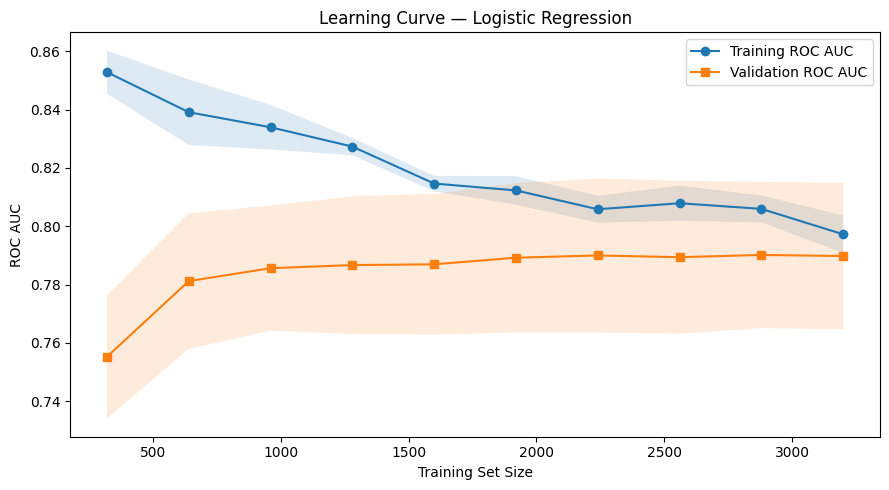

Final training ROC AUC:   0.7972
Final validation ROC AUC: 0.7898
Gap (bias/variance):      0.0074
Diagnosis: Good Fit


In [137]:
from sklearn.model_selection import learning_curve

# Use the same kind of pipeline you cross-validated in 9.2
lc_model = Pipeline(
    [
        ("prep", preprocessor_ens),
        ("model", LogisticRegression(max_iter=2000, random_state=27)),
    ]
)

train_sizes, train_scores, val_scores = learning_curve(
    lc_model,
    X_ens_train,
    y_ens_train,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.10, 1.0, 10),
    n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, "o-", label="Training ROC AUC")
plt.plot(train_sizes, val_mean, "s-", label="Validation ROC AUC")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("Training Set Size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

final_gap = train_mean[-1] - val_mean[-1]
print(f"Final training ROC AUC:   {train_mean[-1]:.4f}")
print(f"Final validation ROC AUC: {val_mean[-1]:.4f}")
print(f"Gap (bias/variance):      {final_gap:.4f}")
print(
    "Diagnosis: High Bias"
    if val_mean[-1] < 0.75
    else "Diagnosis: High Variance"
    if final_gap > 0.05
    else "Diagnosis: Good Fit"
)


### 9.4 Validation Curves

A **validation curve** plots performance vs. a single hyperparameter. Use it to find the optimal hyperparameter value *before* running a full grid search:

- The left side of the curve (low hyperparameter value) typically shows underfitting (high bias)
- The right side shows overfitting (high variance)
- The **peak of the validation score** indicates the optimal value

Replace `'tree__max_depth'` and the parameter range with whatever hyperparameter you want to inspect.

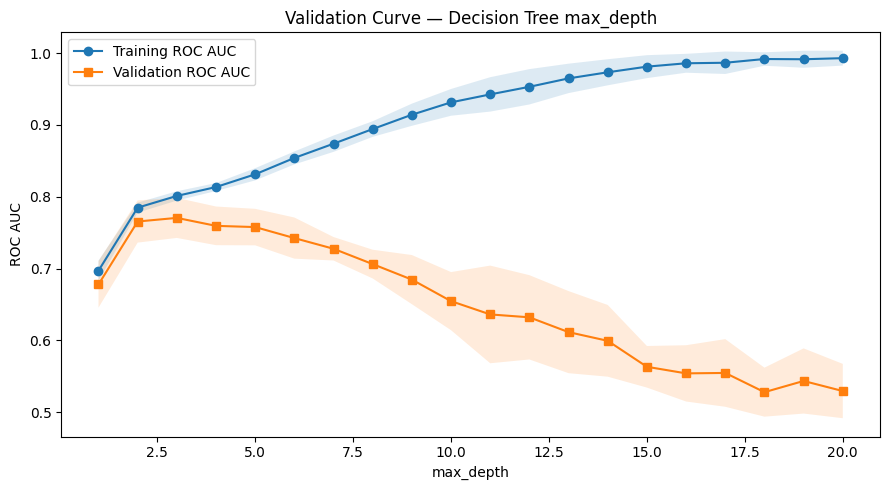

Optimal max_depth from validation curve: 3


In [138]:
from sklearn.model_selection import validation_curve

# Validation curve for Decision Tree max_depth (pipeline = prep + model)
dt_vc_pipe = Pipeline(
    [
        ("prep", preprocessor_ens),
        ("model", DecisionTreeClassifier(random_state=27)),
    ]
)

param_range = np.arange(1, 21)

train_vc, val_vc = validation_curve(
    dt_vc_pipe,
    X_ens_train,
    y_ens_train,
    param_name="model__max_depth",
    param_range=param_range,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
)

plt.figure(figsize=(9, 5))
plt.plot(param_range, train_vc.mean(axis=1), "o-", label="Training ROC AUC")
plt.plot(param_range, val_vc.mean(axis=1), "s-", label="Validation ROC AUC")
plt.fill_between(
    param_range,
    train_vc.mean(axis=1) - train_vc.std(axis=1),
    train_vc.mean(axis=1) + train_vc.std(axis=1),
    alpha=0.15,
)
plt.fill_between(
    param_range,
    val_vc.mean(axis=1) - val_vc.std(axis=1),
    val_vc.mean(axis=1) + val_vc.std(axis=1),
    alpha=0.15,
)
plt.xlabel("max_depth")
plt.ylabel("ROC AUC")
plt.title("Validation Curve — Decision Tree max_depth")
plt.legend()
plt.tight_layout()
plt.show()

optimal_depth_vc = param_range[val_vc.mean(axis=1).argmax()]
print(f"Optimal max_depth from validation curve: {optimal_depth_vc}")


### 9.5 Hyperparameter Tuning with GridSearchCV

`GridSearchCV` exhaustively tests every combination of hyperparameters in the grid. Use it when the search space is small (< ~100 combinations). It fits `n_combinations × n_folds` models total.

Prefix hyperparameter names with the pipeline step name followed by `__`  
(e.g., `'lr__C'` targets the `C` parameter of the step named `'lr'`).

In [139]:
# ── Quick GridSearchCV for Logistic Regression (fast) ─────────────────────────
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Use fewer folds for speed (quick exploration). Switch back to 5 for final.
quick_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=27)

lr_grid_pipe = Pipeline(
    [
        ("prep", preprocessor_ens),
        (
            "lr",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=1500,
                random_state=27,
            ),
        ),
    ]
)

# Tiny grid: 2 × 2 = 4 combos; with 3-fold CV => 12 fits (much faster)
param_grid_lr = {
    "lr__C": [0.1, 1.0],
    "lr__l1_ratio": [0.0, 1.0],
}

grid_lr = GridSearchCV(
    estimator=lr_grid_pipe,
    param_grid=param_grid_lr,
    cv=quick_cv,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)

grid_lr.fit(X_ens_train, y_ens_train)

print(f"Best params:     {grid_lr.best_params_}")
print(f"Best CV ROC AUC: {grid_lr.best_score_:.4f}")

# Evaluate once on the locked test set
best_lr = grid_lr.best_estimator_
y_test_pred = best_lr.predict(X_ens_test)
y_test_proba = best_lr.predict_proba(X_ens_test)[:, 1]

print("\nTest set metrics:")
print(f"  Accuracy: {accuracy_score(y_ens_test, y_test_pred):.4f}")
print(f"  ROC AUC:  {roc_auc_score(y_ens_test, y_test_proba):.4f}")
print(f"  Log loss: {log_loss(y_ens_test, best_lr.predict_proba(X_ens_test)):.4f}")


C:\Users\camjw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best params:     {'lr__C': 0.1, 'lr__l1_ratio': 1.0}
Best CV ROC AUC: 0.7947

Test set metrics:
  Accuracy: 0.9360
  ROC AUC:  0.7814
  Log loss: 0.2066


C:\Users\camjw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 9.6 Hyperparameter Tuning with RandomizedSearchCV

`RandomizedSearchCV` samples a fixed number of random combinations (`n_iter`) from the parameter space. Use it when the search space is large (many hyperparameters or wide ranges). It is more efficient than GridSearch and often finds equally good results.

In [140]:
# ── Quick RandomizedSearchCV for Gradient Boosting (fast) ─────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

quick_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=27)

gb_rand_pipe = Pipeline(
    [
        ("prep", preprocessor_ens),
        ("gb", GradientBoostingClassifier(random_state=27)),
    ]
)

# Small parameter space + low n_iter so it finishes fast
param_dist_gb = {
    "gb__n_estimators": [50, 100],
    "gb__learning_rate": [0.05, 0.1],
    "gb__max_depth": [2, 3],
}

# 8 combos total; sample n_iter=6; with 3-fold CV => 18 fits
rand_gb = RandomizedSearchCV(
    estimator=gb_rand_pipe,
    param_distributions=param_dist_gb,
    n_iter=6,
    cv=quick_cv,
    scoring="roc_auc",
    random_state=27,
    n_jobs=-1,
    refit=True,
)

rand_gb.fit(X_ens_train, y_ens_train)

print(f"Best params:     {rand_gb.best_params_}")
print(f"Best CV ROC AUC: {rand_gb.best_score_:.4f}")

# Quick locked test-set check
best_gb = rand_gb.best_estimator_
y_test_pred = best_gb.predict(X_ens_test)
y_test_proba = best_gb.predict_proba(X_ens_test)[:, 1]

print("\nTest set metrics:")
print(f"  Accuracy: {accuracy_score(y_ens_test, y_test_pred):.4f}")
print(f"  ROC AUC:  {roc_auc_score(y_ens_test, y_test_proba):.4f}")
print(f"  Log loss: {log_loss(y_ens_test, best_gb.predict_proba(X_ens_test)):.4f}")


Best params:     {'gb__n_estimators': 100, 'gb__max_depth': 2, 'gb__learning_rate': 0.05}
Best CV ROC AUC: 0.7871

Test set metrics:
  Accuracy: 0.9360
  ROC AUC:  0.7699
  Log loss: 0.2088


### 9.7 Fair Multi-Model Comparison

Cross-validate all models of interest under **identical conditions** — same folds, same scoring. This ensures performance differences reflect the models themselves, not different evaluation setups.

After tuning, include tuned versions of each model in the comparison for a complete picture.

In [141]:
# FAST fair comparison (≈ 1 minute): fewer models + fewer folds
# Still fair because all models use the same folds + same scoring.

from sklearn.model_selection import StratifiedKFold

quick_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=27)

# Compare a small set of strong candidates
# Key change: for fraud problems, also consider class weighting to improve recall.
lr_base = Pipeline([
    ("prep", preprocessor_ens),
    ("lr", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=27,
    )),
])

rf_pipe = Pipeline([
    ("prep", preprocessor_ens),
    ("rf", RandomForestClassifier(
        n_estimators=80,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=27,
        n_jobs=-1,
    )),
])

gb_pipe = Pipeline([
    ("prep", preprocessor_ens),
    ("gb", GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.1,
        max_depth=3,
        random_state=27,
    )),
])

models_to_compare = {
    "Logistic Regression (balanced)": lr_base,
    "Random Forest (balanced)": rf_pipe,
    "Gradient Boosting": gb_pipe,
}

# Optionally include tuned quick-search models if they exist
if "grid_lr" in globals():
    models_to_compare["LR (GridSearch tuned)"] = grid_lr.best_estimator_
if "rand_gb" in globals():
    models_to_compare["GB (RandomSearch tuned)"] = rand_gb.best_estimator_

comparison_rows = []
for name, pipe in models_to_compare.items():
    cv_res = cross_validate(pipe, X_ens_train, y_ens_train, cv=quick_skf, scoring=scoring, n_jobs=-1)
    row = {"Model": name}

    # Keep these columns in the table (primary selection metric first)
    for metric in [
        "recall_pos",
        "precision_pos",
        "f1_pos",
        "balanced_accuracy",
        "roc_auc",
        "neg_log_loss",
        "accuracy",
    ]:
        vals = cv_res[f"test_{metric}"]
        if metric.startswith("neg_"):
            vals = -vals
            metric = metric.replace("neg_", "")
        row[f"{metric}_mean"] = float(vals.mean())
        row[f"{metric}_std"] = float(vals.std())

    comparison_rows.append(row)

comparison_cv = pd.DataFrame(comparison_rows)

# Sort by fraud recall (highest first). Use tie-breakers so "best" is meaningful
# when several models have the same recall (often 0.0 at the default threshold).
sort_cols = [
    "recall_pos_mean",
    "f1_pos_mean",
    "precision_pos_mean",
    "roc_auc_mean",
]
for c in sort_cols:
    if c not in comparison_cv.columns:
        comparison_cv[c] = np.nan

# Prefer lower log loss if still tied
if "log_loss_mean" in comparison_cv.columns:
    comparison_cv = comparison_cv.sort_values(
        by=sort_cols + ["log_loss_mean"],
        ascending=[False, False, False, False, True],
    )
else:
    comparison_cv = comparison_cv.sort_values(by=sort_cols, ascending=[False, False, False, False])

display(comparison_cv)

top_recall = float(comparison_cv.iloc[0]["recall_pos_mean"]) if len(comparison_cv) else float("nan")
print("\nPrimary metric: recall_pos (fraud recall). This is a quick comparison (3-fold CV).")
if top_recall == 0.0:
    print("Warning: top recall_pos_mean is 0.0. This usually means no model is predicting class 1 at the default threshold.")
    print("In fraud detection, you typically need threshold tuning (or different algorithms/features) to get non-zero recall.")


,Model,recall_pos_mean,recall_pos_std,precision_pos_mean,precision_pos_std,f1_pos_mean,f1_pos_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,log_loss_mean,log_loss_std,accuracy_mean,accuracy_std
0,Logistic Regression (balanced),0.8862,0.0745,0.1176,0.0103,0.2076,0.0177,0.7173,0.0406,0.7896,0.0336,0.8878,0.0743,0.5698,0.0247
1,Random Forest (balanced),0.1654,0.0172,0.2040,0.0405,0.1801,0.0201,0.5595,0.0084,0.7624,0.0384,0.2752,0.0148,0.9035,0.0135
2,Gradient Boosting,0.0197,0.0056,0.1532,0.0752,0.0346,0.0104,0.5056,0.0039,0.7511,0.0298,0.2226,0.0152,0.9298,0.0031
3,LR (GridSearch tuned),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.7947,0.0309,0.2030,0.0078,0.9365,0.0003
4,GB (RandomSearch tuned),0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4999,0.0002,0.7871,0.0350,0.2063,0.0104,0.9363,0.0006



Primary metric: recall_pos (fraud recall). This is a quick comparison (3-fold CV).


### 9.8 Final Evaluation on the Held-Out Test Set

This is the **one and only time** the test set is used. Train your best model(s) on the **full training set** and evaluate on the test set. This is your honest, unbiased estimate of real-world performance.

> **Important:** Do not go back and tune further after seeing the test set results — that would invalidate the evaluation.

Best model selected (by fraud recall): Logistic Regression (balanced)


C:\Users\camjw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


FINAL MODEL EVALUATION (TEST SET) — RECALL-FOCUSED
  Recall (pos=1):    0.6406
  Precision (pos=1): 0.1547
  F1 (pos=1):        0.2492
  Balanced Accuracy:           0.7007
  ROC AUC:                    0.7794
  Log Loss:                   0.4252


C:\Users\camjw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


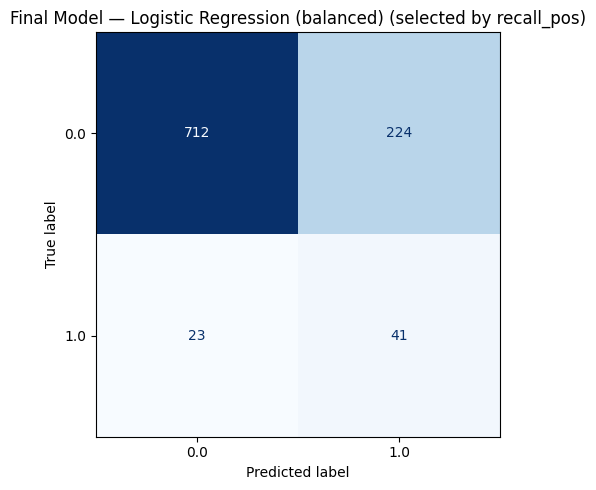

In [142]:
# Identify best model from cross-validation comparison (use training data only)
# Then train it once on full training set and evaluate once on the locked test set.

# Recreate the same candidates used in the fast 9.7 comparison (recall-oriented)
lr_base = Pipeline([
    ("prep", preprocessor_ens),
    ("lr", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=27,
    )),
])

rf_pipe = Pipeline([
    ("prep", preprocessor_ens),
    ("rf", RandomForestClassifier(
        n_estimators=80,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=27,
        n_jobs=-1,
    )),
])

gb_pipe = Pipeline([
    ("prep", preprocessor_ens),
    ("gb", GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.1,
        max_depth=3,
        random_state=27,
    )),
])

candidate_models = {
    "Logistic Regression (balanced)": lr_base,
    "Random Forest (balanced)": rf_pipe,
    "Gradient Boosting": gb_pipe,
}

# Include tuned models if you ran 9.5 / 9.6
if "grid_lr" in globals():
    candidate_models["LR (GridSearch tuned)"] = grid_lr.best_estimator_
if "rand_gb" in globals():
    candidate_models["GB (RandomSearch tuned)"] = rand_gb.best_estimator_

# Choose best model name from the comparison table if available
best_name = None
if "comparison_cv" in globals() and isinstance(comparison_cv, pd.DataFrame) and len(comparison_cv):
    # 9.7 is now sorted by recall_pos_mean desc
    best_name = comparison_cv.iloc[0]["Model"]
elif "comparison_df" in globals() and isinstance(comparison_df, pd.DataFrame) and len(comparison_df):
    best_name = comparison_df.iloc[0]["Model"]

if best_name is None or best_name not in candidate_models:
    # Fallback: pick tuned models if available, else balanced LR
    if "grid_lr" in globals():
        best_name = "LR (GridSearch tuned)"
    elif "rand_gb" in globals():
        best_name = "GB (RandomSearch tuned)"
    else:
        best_name = "Logistic Regression (balanced)"

best_final_model = candidate_models[best_name]
print("Best model selected (by fraud recall):", best_name)

# Train on the full training set
best_final_model.fit(X_ens_train, y_ens_train)

# Final test-set evaluation — done only once
POS_LABEL = globals().get("POS_LABEL", 1)

y_final_pred = best_final_model.predict(X_ens_test)
y_final_proba = best_final_model.predict_proba(X_ens_test)

final_recall = recall_score(y_ens_test, y_final_pred, pos_label=POS_LABEL, zero_division=0)
final_precision = precision_score(y_ens_test, y_final_pred, pos_label=POS_LABEL, zero_division=0)
final_f1 = f1_score(y_ens_test, y_final_pred, pos_label=POS_LABEL, zero_division=0)
final_bal_acc = balanced_accuracy_score(y_ens_test, y_final_pred)
final_roc_auc = roc_auc_score(y_ens_test, y_final_proba[:, 1])
final_logloss = log_loss(y_ens_test, y_final_proba)

print("=" * 60)
print("FINAL MODEL EVALUATION (TEST SET) — RECALL-FOCUSED")
print("=" * 60)
print(f"  Recall (pos={POS_LABEL}):    {final_recall:.4f}")
print(f"  Precision (pos={POS_LABEL}): {final_precision:.4f}")
print(f"  F1 (pos={POS_LABEL}):        {final_f1:.4f}")
print(f"  Balanced Accuracy:           {final_bal_acc:.4f}")
print(f"  ROC AUC:                    {final_roc_auc:.4f}")
print(f"  Log Loss:                   {final_logloss:.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_ens_test, y_final_pred, cmap="Blues", colorbar=False)
plt.title(f"Final Model — {best_name} (selected by recall_pos)")
plt.tight_layout(); plt.show()


### 9.9 Final Confusion Matrix & Classification Report

Examine where the best model succeeds and where it struggles. Compare precision and recall for each class to determine whether the model is better at avoiding false positives or false negatives — and whether that trade-off aligns with the business context.

Classification Report (test set):
              precision    recall  f1-score   support

         0.0       0.97      0.76      0.85       936
         1.0       0.15      0.64      0.25        64

    accuracy                           0.75      1000
   macro avg       0.56      0.70      0.55      1000
weighted avg       0.92      0.75      0.81      1000



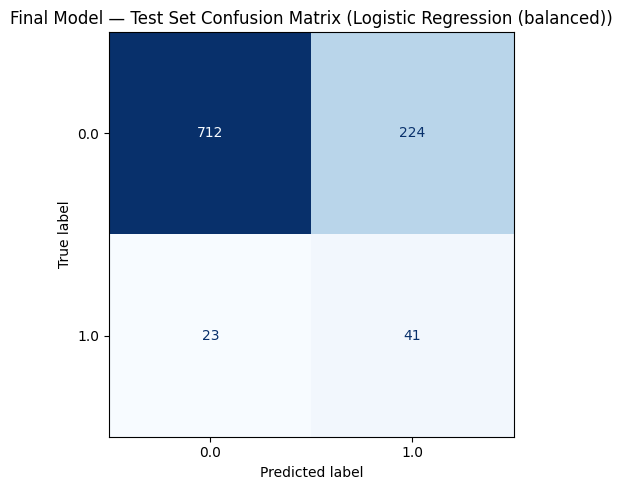

In [143]:
from sklearn.metrics import classification_report

# Final test-set report (use outputs from 9.8)
print("Classification Report (test set):")
print(classification_report(y_ens_test, y_final_pred, zero_division=0))

# Confusion matrix plot
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_ens_test,
    y_final_pred,
    cmap="Blues",
    colorbar=False,
)
cm_disp.ax_.set_title(f"Final Model — Test Set Confusion Matrix ({best_name})")
plt.tight_layout()
plt.show()


---
## Summary: The Complete ML Pipeline

| Step | Chapter | What You Did |
|------|---------|-------------|
| 1 | — | Imported all libraries |
| 2 | Ch. 6 | Loaded and inspected the raw dataset |
| 3 | Ch. 6 | Built `univariate()` to profile every column with stats and charts |
| 4 | Ch. 7 | Cleaned categorical text, datetime features, rare categories, skew, missing values, and outliers |
| 5 | Ch. 8 | Built `bivariate_stats()` to find statistically significant features; created bivariate charts |
| 6 | — | Defined the modeling goal: causal vs. predictive, numeric vs. categorical label |
| 7A | Ch. 9–10 | Built and diagnosed a causal MLR model: coefficients, VIF, residuals, transformations |
| 7B | Ch. 9–10 | Built a causal logistic regression: odds ratios, in-sample classification metrics |
| 8A | Ch. 11–12 | Built predictive linear regression with train/test split, greedy backward removal, and decision tree regressor |
| 8B | Ch. 13–14 | Built decision tree classifiers (two-class + multi-class) and all six ensemble methods |
| 9 | Ch. 15 | Evaluated with cross-validation, diagnosed with learning/validation curves, tuned with GridSearch and RandomizedSearch, and made the final test-set evaluation |

> **Next steps after completing this pipeline:**
> - Document your findings and model interpretation for stakeholders
> - Deploy the final model (pickle/joblib the pipeline)
> - Set up monitoring for model drift over time
> - Collect new data and retrain periodically


In [144]:
import json
from pathlib import Path
import joblib

# Save the final selected pipeline from 9.8
if "best_final_model" not in globals():
    raise NameError("Run Section 9.8 first so `best_final_model` exists.")

out_dir = Path.cwd()
model_path = out_dir / "model1.sav"
meta_path = out_dir / "model1.meta.json"

joblib.dump(best_final_model, model_path)

meta = {
    "selected_model_name": globals().get("best_name", None),
    "pos_label": globals().get("POS_LABEL", 1),
    "saved_model": str(model_path.name),
}
meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved model to: {model_path}")
print(f"Saved metadata to: {meta_path}")


Saved model to: c:\Users\camjw\OneDrive\Desktop\BYU\9. Winter 2026\IS 455 - Mark Keith\shopProject\IS-455-Shop-DB\ML\model1.sav
Saved metadata to: c:\Users\camjw\OneDrive\Desktop\BYU\9. Winter 2026\IS 455 - Mark Keith\shopProject\IS-455-Shop-DB\ML\model1.meta.json
